# Cross-validation for Model_Akaike

Code by Caroline Juang, c.juang@columbia.edu

February 20, 2024, June 2026

Implement Leave-One-Out Cross Validation, and compare the fully-calibrated Climate-Burned Area model and the cross-validated model.

In [1]:
# import
from customconfig import *
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy.stats.mstats import theilslopes
import joblib # for saving models
from itertools import compress
import colorcet # more colormaps

MANUALLY DEFINED, no forest models:
['ecoprov1', 'ecoprov3', 'ecoprov7', 'ecoprov18', 'ecoprov21']
MANUALLY DEFINED, no nonforest models:
[]
Ensemble is 500 members


In [2]:
# suppress numpy divide by zero warning
np.seterr(divide='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## User input

In [3]:
# customize seasons for climate variables

years = np.arange(firstyear, finalyear+1)

# importing data string
# climindname is not used except for saving to a folder
# Read the climate index from the .txt file
with open('0_climindname.txt', 'r') as f:
    climindname = f.read().strip()
print(climindname +' will be used for the SST gradient')
#data_string = 'data\\'
data_string = 'data//'
#model_string = 'model\\'+climindname+'\\'
model_string = 'model//'+climindname+'//'
#predict_string = 'predicted\\'+climindname+'\\'
predict_string = 'predicted//'+climindname+'//'

patch125-155_nino3-34 will be used for the SST gradient


## Scripts

For now, keep these separate from customscripts, just to make sure the model does not break. (6/18/2026)

In [4]:
# calculate AICc for variables

def getAICc(rvalue, nyears, npredictors):
    """
    Calculate the AICc, which is the Akaike Information Criterion (AIC)
    with bias correction for small sample sizes (AICc). 
    Inputs are the variables needed for the calculation. 
    Output is a single value of the AICc.
    r = r-value calculated from a Pearson Correlation
    nyears = number of years in the timeseries
    npredictors = number of x-variables used in the model
    """
    # calculate AIC
    aic = nyears * np.log(1-rvalue**2) + 2*(npredictors+1)
    # calculate AIC with bias correction for small sample size
    aicc = aic + (2*(npredictors+1)*(npredictors+2)) / (nyears - npredictors - 2)
    return aicc

In [5]:
# average climate variables, within a selected season

def annualDetrend(data):
    """
    This intakes an array of current ecoregion's climate variable of annual averages (data), 
    Output: an array of the yearly data, detrended so the slope of the data is zero.
    Requirements: 
    """

    # detrend the data
    xnum = np.arange(0,len(data))
    reg = linregress(xnum, data)
    m = reg.slope
    b = reg.intercept
    regpredict = m*xnum + b
    # normalize by subtracting the linear regression
    tmpdatanorm = (data - regpredict) + b

    return tmpdatanorm

In [6]:
# get amount in forest

def in_allregion(variable, thisregion):
    """
    For getting the average values only in this particular region of the western US.
    Requirements: the western US study area.
    Returns one weighted average of the variable for each timestep.
    """
    thisregion = westUS*thisregion # get in the study area
    weightedsum = (variable*thisregion).sum(dim=['X','Y'], skipna=True)
    regionsum = thisregion.sum()
    return  weightedsum / regionsum

def in_forest(variable, thisregion):
    """
    For getting the average values only in a forest area.
    Requirements: the forest netCDF.
    Returns one weighted average of the variable for each timestep.
    """
    forestregion = forest*thisregion # get in the region
    weightedsum = (variable*(forestregion)).sum(dim=['X','Y'], skipna=True)
    forestsum = (forestregion).sum()
    return  weightedsum / forestsum


def in_nonforest(variable, thisregion):
    """
    For getting the average values only in a nonforested area in the western US.
    Requirements: the forest netCDF, a mask of the western US.
    Returns one weighted average of the variable for each timestep and the selected region.
    """
    nonforestregion = nonforest*thisregion # get in the region
    weightedsum = (variable*(nonforestregion)).sum(dim=['X','Y'], skipna=True)
    nonforestsum = (nonforestregion).sum()
    return  weightedsum / nonforestsum

## import ecoregion data

In [7]:
# import western US study area
westUS_string = '12km//study_area//westUS.nc'
westUS = xr.open_dataset(directory + westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
forest_string = '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(directory + forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)

In [8]:
# a few changes from customconfig

# ecoregion info
prov_abbr_names = prov_abbr_names[1:] # remove allwestUS present in customconfig

# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

## Import fire, climate data
from `Data_CreateModelData`

model data from `Model_Akaike` and `Model_ENSOfull12-2022`

In [9]:
# import the errormatrix (from Run_updateModel)
tmp_fname = predict_string + "Model_ENSOFull_ErrorSequence.txt"
errormatrix = np.loadtxt(tmp_fname).astype(int) # load as integer

In [10]:
# import fire data, both modis and wumi databases
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

In [11]:
# import model data

dfframesall = {}
dfframesfor = {}
dfframesnon = {}

for iecoreg in np.arange(len(province_num)):
    filename = data_string + 'climate_ecoprovinces_'
    dfframesall[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_all.txt').set_index('Unnamed: 0')
    dfframesfor[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_for.txt').set_index('Unnamed: 0')
    dfframesnon[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_non.txt').set_index('Unnamed: 0')

# in km2, the minimum fire sum for model to be valid
minfiresum = 200

# variables with known correlation with burned area in forest 
# in current year
clim_negcorr = ['wetdays', 'prec', 'rh'] # should be negative
clim_poscorr = ['vpd', 'tmax', 'tmin', 'solar'] # should be positive
clim_poscorrboth = ['wind'] # forest and nonforest
clim_correxclude = ['rh y0', 'tmean y0',
                 'tmean y-1','rh y-1',
                 'wind y-1', 'tmax y-1','tmin y-1',
                 'wetdays y-1','solar y-1','vpd y-1'] # remove most of the prior-year variables

In [12]:
# import climate with detrended SST scenario
# this is from Model_ENSOfull12-2022 where climate under a detrended gSST
# scenario is used (observed climate minus the contribution from gSST)

dfsstclimfor = {}
dfsstclimnon = {}

for thisname in dfnames:
    filename = predict_string + 'Climate_' + thisname + '_sstpred_'
    filenameend = 'DeTrendClimObs_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
    dfsstclimfor[thisname] = pd.read_csv(filename + 'for_' + filenameend).set_index('Unnamed: 0')
    dfsstclimnon[thisname] = pd.read_csv(filename + 'non_' + filenameend).set_index('Unnamed: 0')


## Import climate data
from `Data_CreateModelData`

In [13]:
# storage for each model's variable indices
dfmodelfor = {}
dfmodelnon = {}

# storage for timeseries of BA_model 
# (all values predicted from LOOCV-ed model)
BACVpredfor = {}
BACVprednon = {}

# storage for detrended versions of timeseries of BA model
BACVsstfor = {}
BACVsstnon = {}

## Correlation and regression

Akaike Information Criterion - https://doi.org/10.1109/TAC.1974.1100705

```AIC = Nyears * log(1-r.^2) + 2*(Npredictors+1)```

* `r^2` = square of the correlation coefficient
* `Nyears` = number of years in the timeseries
* `Npredictors` = the number of timeseries you're using as predictors
* rewarded for large sample size, penalized for adding more number of predictors

regression and time series model selection in small samples: https://doi.org/10.1093/biomet/76.2.297

```AICc = AIC + (2*(Npredictors+1)*(Npredictors+2))/(Nyears - Npredictors - 2)```
* bias correction on the AIC

### Leave One Out Cross Validation (LOOCV)

In [14]:
# construct what to leave out
nleaveout = 3

numbers = list(range(len(years)))

# Divide the list into groups of 3
groupsleaveout = [numbers[i:i+3] for i in range(0, len(numbers), 3)]

# error ensemble
nensemble = 500 # number of ensemble members

In [15]:
# have a log version of WUMI (for error calculation)
# BAclimpred is already log
BA_obsfor = np.ma.masked_invalid(np.log10(wumifor)).filled(0)
BA_obsnon = np.ma.masked_invalid(np.log10(wuminon)).filled(0)
BA_obsfor = pd.DataFrame(BA_obsfor, index=years, columns=dfnames)
BA_obsnon = pd.DataFrame(BA_obsnon, index=years, columns=dfnames)

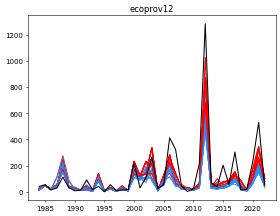

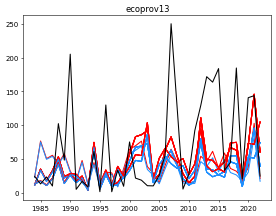

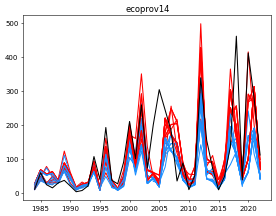

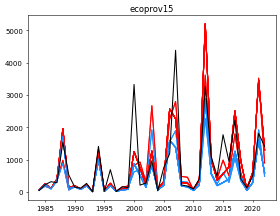

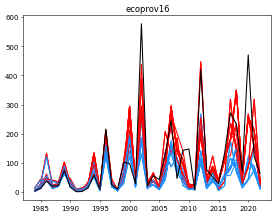

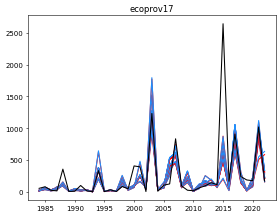

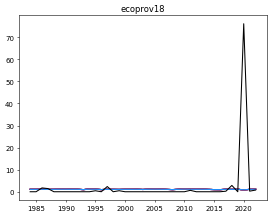

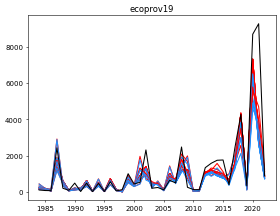

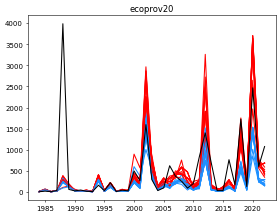

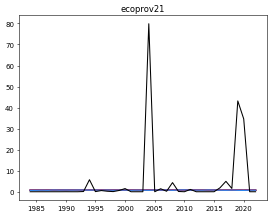

In [ ]:
# same model for FOREST area

print('FOREST')
landname = 'for'
labels = dfframesfor['ecoprov1'].columns.values # each climate variable

for iregion in np.arange(len(province_num)):
    

    print('+++ model for ' + dfnames[iregion] + '\t AICC \t r-value')
    # PLOT
    fig, ax = plt.subplots(dpi=50)
    ax.plot(years, wumifor.iloc[:,iregion], color='k', zorder=2)
    ax.set_title(dfnames[iregion])
    BACVtmpstorage = np.zeros((len(wuminon.iloc[:,0]), 
                               len(errormatrix)))  # storage
    BACVtmpstorageDT = np.zeros((len(wuminon.iloc[:,0]), 
                                 len(errormatrix)))  # storage for dt scenario
    thisname = dfnames[iregion]
    for leavethis in groupsleaveout:
        nameslist = [] # use this for-loop to get df column names
        for j in np.arange(0,nensemble):
            thisnamek = thisname +'_'+str(j) # unique for-loop to get col names
            nameslist.append(thisnamek)
        #print('these groups left out: {}'.format(leavethis))
        tmpr = np.zeros(len(labels)) # storage for regression correlation
        tmpr_clim = np.zeros(len(labels)) # storage for r corr, clim vs. BA
        tmpr_climDT = np.zeros(len(labels)) # storage for r corr, climDT vs. BA_DT
        aicc = np.zeros(len(labels)) # storage for aicc values for each set of reg fit
        tmpaicc = [] # storage for aicc values for each model
        tmpi = [] # empty list of indices for variables
    
        # get observed ecoregion burned area, but set min value
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wumifor.iloc[:,iregion])).filled(0))
    
        # leave one out!
        tmpfire = np.delete(tmpfire, leavethis)
        
        tmpfiremin = tmpfire[tmpfire!=0].min()
        tmpfire[tmpfire==0] = tmpfiremin # replace 0 with minimum nonzero value
        tmpfireDT = annualDetrend(tmpfire)

        tmpfiresum = wumifor.iloc[:,iregion].sum()
        
        for i, label in enumerate(labels):
            tmpclim = np.asarray(dfframesfor[dfnames[iregion]][label].values)
            # leave one out! 
            tmpclim = (np.delete(tmpclim, leavethis)).reshape(-1,1)
            tmpclimDT = annualDetrend(tmpclim.flatten())
            reg = LinearRegression() # least squares
            reg.fit(tmpclim, tmpfire)
            tmppredict = reg.predict(tmpclim)
            tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
            # calculate AICc for each
            nyears = len(tmpfire)
            npredictors = reg.n_features_in_
            aicc[i] = getAICc(tmpr[i], nyears, npredictors)
            # compare signs
            tmpr_clim = pearsonr(tmpclim.flatten(), tmpfire)
            tmpr_climDT = pearsonr(tmpclimDT, tmpfireDT)
            # check if the correlation is right sign intuitively
            tmplabeljustvar = label.split(' ')[0]
            tmplabeljustyr = label.split(' ')[1]
            tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
            # wrong signs
            tmpwrong1 = (tmpr_clim.statistic > 0) & ((tmplabeljustvar in clim_negcorr)&(tmplabeljustyr in ['y0']))
            tmpwrong2 = (tmpr_clim.statistic < 0) & ((tmplabeljustvar in clim_poscorr)&(tmplabeljustyr in ['y0']))
            tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
            tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
            if tmpwrong1 or tmpwrong2 or tmpwrong3 or tmpwrong4:
                aicc[i] = 99 # overwrite the AICc value
            # check if they are the same sign
            tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
            tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
            #if tmpsign==False:
            #    print('\tSIGN CHANGE ' + label + '\t'+
            #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
            #if tmppvalue==False:
            #    print('\tDT INSIGNIFICANT ' + label + '\t'+
            #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
            if (tmpsign==False) or (tmppvalue==False):
                aicc[i] = 99 # overwrite the AICc value
                #print('\tOverwrite AICc')
        # get minimum
        [iminaicc, minaicc] = np.argmin(aicc), np.min(aicc)
        tmpi.append(iminaicc) # add min to list of variables
        tmpaicc.append(minaicc) # add aicc value to list
        
        if (minaicc>0) or (tmpfiresum<minfiresum): # we overwrite the model and exit
            # need all write/output requirements because we're EXITING  THIS leavethis in GROUPSLEAVEOUT!!!
            tmpclim = np.asarray(dfframesfor[dfnames[iregion]].iloc[:,tmpi].values)
            # leave one out!
            tmpclim = np.delete(tmpclim, leavethis).reshape(-1,1)
            reg = LinearRegression()
            reg.fit(tmpclim, tmpfire)
            reg.coef_ = np.asarray([0]) # change coeff to 0
            reg.intercept_ = np.asarray(tmpfire.mean())
            #f_vars.write(labels[iminaicc] + '\n' + str(tmpclim.flatten()) + '\n') # write variable data to file
            #print('\tAICc POSITIVE--EXIT')
            #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
            #      str(np.round(tmpr[iminaicc], decimals=3)))
            tmpcoef = reg.coef_
            tmpintercept = reg.intercept_
 
            # re-predict with full timeseries
            tmpclim = np.asarray(dfframesfor[dfnames[iregion]][label].values).reshape(-1,1)
            tmppred = reg.predict(tmpclim)
    
            dfmodelfor[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
            
            # (9/8/2024) ADD ERROR ENSEMBLE
            
            # error time series (BA obs - model)
            tmpBA_error_log10 = BA_obsfor.iloc[:,iregion] - tmppred
            # get nensemble of sequence of errors
            tmpBA_randomerror = np.empty((0,len(years)))
            for j in np.arange(0,nensemble):
                tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
                tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                                   tmpcolerror], axis=0)
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred = np.log10(tmpBA_mod_plus_error)

            # (11/17/2025) Predict climate under detrended gSST scenario
            # fits it to the model trained on observed climate
            tmpX = dfsstclimfor[dfnames[iregion]].iloc[:,tmpi] 
            tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
            # add error ensemble
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred_DT = np.log10(tmpBA_mod_plus_error)
            
    
            # save the predicted values (only the out-of-sample ones
            BACVtmpstorage[leavethis] = tmppred.iloc[leavethis,:]
            BACVtmpstorageDT[leavethis] = tmppred_DT.iloc[leavethis,:]

            # PLOT
            ax.plot(years, 10**(tmppred.mean(axis=1)), color='red', zorder=0)
            ax.plot(years, 10**(tmppred_DT.mean(axis=1)), color='dodgerblue', zorder=0)
            
            continue # leave this loop
        
        # calculate residuals from one-variable model
        # and leave one out!
        tmpclim = dfframesfor[dfnames[iregion]].iloc[:,tmpi].drop(leavethis).values
        reg = LinearRegression()
        reg.fit(tmpclim, tmpfire)
        tmppredictprior = reg.predict(tmpclim)
    
        #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
        #          str(np.round(tmpr[iminaicc], decimals=3)))
        
        # define starting difference in aicc to get the for-loop to start
        diffaicc = -3
        # multiple regression using remaining predictor, until aicc is not improved
        while diffaicc < -2:
            # add another variable to get new model
            # calculate residuals
            tmpresids = np.log10((10**tmpfire)/(10**tmppredictprior))
            # go through each variable and get the correlation
            tmpr = np.zeros(len(labels)) # storage for regression correlation
            for i, label in enumerate(labels):
                tmpclimnew = np.asarray(dfframesfor[dfnames[iregion]][label])
                # leave one out!
                tmpclimnew = np.delete(tmpclimnew, leavethis).reshape(-1,1)
                tmpclimprior = dfframesfor[dfnames[iregion]].iloc[:,tmpi].drop(leavethis).values
                tmpX = np.hstack((tmpclimprior, tmpclimnew)) # all X variables
                tmpclimnewDT = annualDetrend(tmpclimnew.flatten())
                tmpresidsDT = annualDetrend(tmpresids)
                reg = LinearRegression() # least squares
                reg.fit(tmpX, tmpfire)
                tmppredict = reg.predict(tmpX)
                tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
                # calculate AICc for each
                nyears = len(tmpfire)
                npredictors = reg.n_features_in_
                aicc[i] = getAICc(tmpr[i], nyears, npredictors)
                # compare signs
                tmpr_clim = pearsonr(tmpclimnew.flatten(), tmpresids)
                tmpr_climDT = pearsonr(tmpclimnewDT, tmpresidsDT)
                # check if the correlation is right sign intuitively
                tmplabeljustvar = label.split(' ')[0]
                tmplabeljustyr = label.split(' ')[1]
                tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
                # wrong signs
                tmpwrong1 = (tmpr_clim.statistic > 0) & ((tmplabeljustvar in clim_negcorr)&(tmplabeljustyr in ['y0']))
                tmpwrong2 = (tmpr_clim.statistic < 0) & ((tmplabeljustvar in clim_poscorr)&(tmplabeljustyr in ['y0']))
                tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
                tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
                if tmpwrong1 or tmpwrong2 or tmpwrong3 or tmpwrong4:
                    aicc[i] = 99 # overwrite the AICc value
    
                # check if they are the same sign
                tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
                tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
                #if tmpsign==False:
                #    print('\tSIGN CHANGE ' + label + '\t'+
                #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
                #if tmppvalue==False:
                #    print('\tDT INSIGNIFICANT ' + label + '\t'+
                #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
                if (tmpsign==False) or (tmppvalue==False):
                    aicc[i] = 99 # overwrite the AICc value
                    #print('\tOverwrite AICc')
    
            # get minimum
            [iminaicc, minaicc] = np.nanargmin(aicc), np.nanmin(aicc)
            # check aicc value to previous value
            diffaicc = minaicc - tmpaicc[-1]
            # check if diff aicc is small enough before continuing
            #print('diffaicc = {:} - {:}'.format(minaicc, tmpaicc[-1]))
            if (diffaicc >= -2):
                #print('difference is too big, EXIT ' + str(diffaicc)) 
                continue # exit loop
            else:
                # continue this part if aicc < -2
                tmpi.append(iminaicc) # add min to list of variables
                tmpaicc.append(minaicc) # add aicc value to list
                #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
                #          str(np.round(tmpr[iminaicc], decimals=3)))
    
                # calculate residuals from this current model
                tmpX = dfframesfor[dfnames[iregion]].iloc[:,tmpi].drop(leavethis) # all the variables
                reg = LinearRegression()
                reg.fit(tmpX, tmpfire) # fit the final model
                tmppredictprior = reg.predict(tmpX)
    
        # fit the final model - keep all of the timeseries in!
        tmpX = dfframesfor[dfnames[iregion]].iloc[:,tmpi] 
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wumifor.iloc[:,iregion])).filled(0))
        reg.fit(tmpX, tmpfire) # fit the final model
        tmppred = reg.predict(tmpX) # predicted BA

        # (9/8/2024) ADD ERROR ENSEMBLE
        # create random error matrix (with replacement, index left in)
        istop = 0
        iyears = np.arange(0,len(years)) # index of each year
    
        # error time series (BA obs - model)
        tmpBA_error_log10 = BA_obsfor.iloc[:,iregion] - tmppred
        # get nensemble of random errors
        tmpBA_randomerror = np.empty((0,len(years)))
        for j in np.arange(0,nensemble):
            tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
            tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                               tmpcolerror], axis=0)
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred = np.log10(tmpBA_mod_plus_error)

        # (11/17/2025) Predict climate under detrended gSST scenario
        # fits it to the model trained on observed climate
        tmpX = dfsstclimfor[dfnames[iregion]].iloc[:,tmpi] 
        tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
        # add error ensemble
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred_DT = np.log10(tmpBA_mod_plus_error)
        
        # PLOT
        ax.plot(years, 10**(tmppred.mean(axis=1)), color='red', zorder=0)
        ax.plot(years, 10**(tmppred_DT.mean(axis=1)), color='dodgerblue', zorder=0)
    
        # save the predicted values (only the out-of-sample ones)
        tmppred.columns = nameslist # rename columns to ecoprovince_k
        tmppred_DT.columns = nameslist
        BACVtmpstorage[leavethis] = tmppred.iloc[leavethis,:]
        BACVtmpstorageDT[leavethis] = tmppred_DT.iloc[leavethis,:]
        
        
        dfmodelfor[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
    #print(BACVtmpstorage)
    # turn it into a pandas dataframe
    BACVtmpstorage_df = pd.DataFrame(BACVtmpstorage, index=years, columns=nameslist)
    BACVtmpstorageDT_df = pd.DataFrame(BACVtmpstorageDT, index=years, columns=nameslist)
    # store it for the ecoprovince
    BACVpredfor[dfnames[iregion]] = BACVtmpstorage_df
    BACVsstfor[dfnames[iregion]] = BACVtmpstorageDT_df

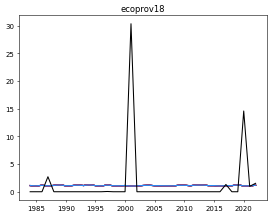

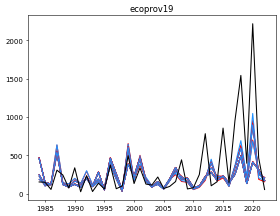

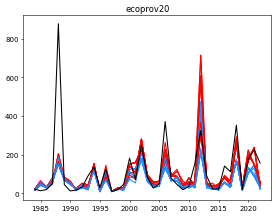

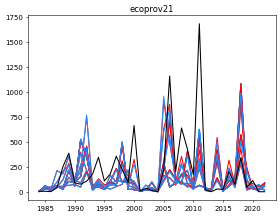

In [ ]:
# same model for NONFOREST area
print('NONFOREST')
landname = 'non'
#modeloutputfile = model_string + 'modeloutput_burnarea_'+landname+'.txt'
#f = open(modeloutputfile, 'w') # print to this file
labels = dfframesnon['allwestUS'].columns.values # each climate variable

for iregion in np.arange(len(province_num)):
    print('+++ model for ' + dfnames[iregion] + '\t AICC \t r-value')
    BACVtmpstorage = np.zeros((len(wuminon.iloc[:,0]), 
                               len(errormatrix))) # storage
    BACVtmpstorageDT = np.zeros((len(wuminon.iloc[:,0]), 
                                 len(errormatrix))) # storage for dt scenario
    
    thisname = dfnames[iregion]
    # PLOT
    fig, ax = plt.subplots(dpi=50)
    ax.plot(years, wuminon.iloc[:,iregion], color='k', zorder=2)
    ax.set_title(dfnames[iregion])

    for leavethis in groupsleaveout:
        nameslist = [] # use this for-loop to get df column names
        for j in np.arange(0,nensemble):
            thisnamek = thisname +'_'+str(j) # unique for-loop to get col names
            nameslist.append(thisnamek)
        tmpr = np.zeros(len(labels)) # storage for regression correlation
        tmpr_clim = np.zeros(len(labels)) # storage for r corr, clim vs. BA
        tmpr_climDT = np.zeros(len(labels)) # storage for r corr, climDT vs. BA_DT
        aicc = np.zeros(len(labels)) # storage for aicc values for each set of reg fit
        tmpaicc = [] # storage for aicc values for each model
        tmpi = [] # empty list of indices for variables
    
        # get observed ecoregion burned area, but set min value
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wuminon.iloc[:,iregion])).filled(0))

        # leave one out!
        tmpfire = np.delete(tmpfire, leavethis)
        
        tmpfiremin = tmpfire[tmpfire!=0].min()
        tmpfire[tmpfire==0] = tmpfiremin # replace 0 with minimum nonzero value
        tmpfireDT = annualDetrend(tmpfire)
        
        tmpfiresum = wuminon.iloc[:,iregion].sum()
        
        for i, label in enumerate(labels):
            tmpclim = np.asarray(dfframesnon[dfnames[iregion]][label].values)
            # leave one out! 
            tmpclim = (np.delete(tmpclim, leavethis)).reshape(-1,1)
            tmpclimDT = annualDetrend(tmpclim.flatten())
            reg = LinearRegression() # least squares
            reg.fit(tmpclim, tmpfire)
            tmppredict = reg.predict(tmpclim)
            tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
            # calculate AICc for each
            nyears = len(tmpfire)
            npredictors = reg.n_features_in_
            aicc[i] = getAICc(tmpr[i], nyears, npredictors)
            # compare signs
            tmpr_clim = pearsonr(tmpclim.flatten(), tmpfire)
            tmpr_climDT = pearsonr(tmpclimDT, tmpfireDT)
            # check if the correlation is right sign physically
            tmplabeljustvar = label.split(' ')[0]
            tmplabeljustyr = label.split(' ')[1]
            tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
            # wrong signs
            tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
            tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
            if tmpwrong3 or tmpwrong4:
                aicc[i] = 99 # overwrite the AICc value
                
            # check if they are the same sign
            tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
            tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
            #if tmpsign==False:
            #    print('\tSIGN CHANGE ' + label + '\t'+
            #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
            #if tmppvalue==False:
            #    print('\tDT INSIGNIFICANT ' + label + '\t'+
            #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
            if (tmpsign==False) or (tmppvalue==False):
                aicc[i] = 99 # overwrite the AICc value
                #print('\tOverwrite AICc')
        # get minimum
        [iminaicc, minaicc] = np.argmin(aicc), np.min(aicc)
        tmpi.append(iminaicc) # add min to list of variables
        tmpaicc.append(minaicc) # add aicc value to list
    
        if (minaicc>0) or (tmpfiresum<minfiresum): # we overwrite the model and exit
            # need all write/output requirements because we're EXITING THIS leavethis in GROUPSLEAVEOUT!!!
            tmpclim = np.asarray(dfframesnon[dfnames[iregion]].iloc[:,tmpi].values)
            # leave one out!
            tmpclim = np.delete(tmpclim, leavethis).reshape(-1,1)
            reg = LinearRegression()
            reg.fit(tmpclim, tmpfire)
            reg.coef_ = np.asarray([0]) # change coeff to 0
            reg.intercept_ = np.asarray(tmpfire.mean())
            #f_vars.write(labels[iminaicc] + '\n' + str(tmpclim.flatten()) + '\n') # write variable data to file
            #print('\tAICc POSITIVE--EXIT')
            #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
            #      str(np.round(tmpr[iminaicc], decimals=3)))
            
            tmpcoef = reg.coef_
            tmpintercept = reg.intercept_
 
            # re-predict with full timeseries
            tmpclim = np.asarray(dfframesnon[dfnames[iregion]][label].values).reshape(-1,1)
            tmppred = reg.predict(tmpclim)
    
            dfmodelnon[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
            
            # (9/8/2024) ADD ERROR ENSEMBLE
            # use sequence of errors imported
            istop = 0
            iyears = np.arange(0,len(years)) # index of each year
            # error time series (BA obs - model)
            tmpBA_error_log10 = BA_obsnon.iloc[:,iregion] - tmppred
            # get nensemble of random errors
            tmpBA_randomerror = np.empty((0,len(years)))
            for j in np.arange(0,nensemble):
                tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
                tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                                   tmpcolerror], axis=0)
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred = np.log10(tmpBA_mod_plus_error)

            # (11/17/2025) Predict climate under detrended gSST scenario
            # fits it to the model trained on observed climate
            tmpX = dfsstclimnon[dfnames[iregion]].iloc[:,tmpi] 
            tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
            # add error ensemble
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred_DT = np.log10(tmpBA_mod_plus_error)
            
    
            # save the predicted values (only the out-of-sample ones)
            BACVtmpstorage[leavethis] = tmppred.iloc[leavethis,:]
            BACVtmpstorageDT[leavethis] = tmppred_DT.iloc[leavethis,:]

            # PLOT
            ax.plot(years, 10**(tmppred.mean(axis=1)), color='red', zorder=0)
            ax.plot(years, 10**(tmppred_DT.mean(axis=1)), color='dodgerblue', zorder=0)
            continue # leave this loop
        
        # calculate residuals from one-variable model
        # and leave one out!
        tmpclim = dfframesnon[dfnames[iregion]].iloc[:,tmpi].drop(leavethis)
        reg = LinearRegression()
        reg.fit(tmpclim, tmpfire)
        tmppredictprior = reg.predict(tmpclim)
    
        #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
        #          str(np.round(tmpr[iminaicc], decimals=3)))
        
        # define starting difference in aicc to get the for-loop to start
        diffaicc = -3
        # multiple regression using remaining predictor, until aicc is not improved
        while diffaicc < -2:
            # add another variable to get new model
            # calculate residuals
            tmpresids = np.log10((10**tmpfire)/(10**tmppredictprior))
            # go through each variable and get the correlation
            tmpr = np.zeros(len(labels)) # storage for regression correlation
            for i, label in enumerate(labels):
                tmpclimnew = np.asarray(dfframesnon[dfnames[iregion]][label])
                # leave one out! 
                tmpclimnew = np.delete(tmpclimnew, leavethis).reshape(-1,1)
                tmpclimprior = dfframesnon[dfnames[iregion]].iloc[:,tmpi].drop(leavethis)
                tmpX = np.hstack((tmpclimprior, tmpclimnew)) # all X variables
                tmpclimnewDT = annualDetrend(tmpclimnew.flatten())
                tmpresidsDT = annualDetrend(tmpresids)
                reg = LinearRegression() # least squares
                reg.fit(tmpX, tmpfire)
                tmppredict = reg.predict(tmpX)
                tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
                # calculate AICc for each
                nyears = len(tmpfire)
                npredictors = reg.n_features_in_
                aicc[i] = getAICc(tmpr[i], nyears, npredictors)
                # compare signs
                tmpr_clim = pearsonr(tmpclimnew.flatten(), tmpresids)
                tmpr_climDT = pearsonr(tmpclimnewDT, tmpresidsDT)
                # check if correlation is the right sign physically
                tmplabeljustvar = label.split(' ')[0]
                tmplabeljustyr = label.split(' ')[1]
                tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
                # wrong signs
                tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
                tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
                if tmpwrong3 or tmpwrong4:
                    aicc[i] = 99 # overwrite the AICc value
                # check if they are the same sign
                tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
                tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
                #if tmpsign==False:
                #    print('\tSIGN CHANGE ' + label + '\t'+
                #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
                #if tmppvalue==False:
                #    print('\tDT INSIGNIFICANT ' + label + '\t'+
                #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
                if (tmpsign==False) or (tmppvalue==False):
                    aicc[i] = 99 # overwrite the AICc value
                    #print('\tOverwrite AICc')
    
            # get minimum
            [iminaicc, minaicc] = np.nanargmin(aicc), np.nanmin(aicc)
            # check aicc value to previous value
            diffaicc = minaicc - tmpaicc[-1]
            # check if diff aicc is small enough before continuing
            #print('diffaicc = {:} - {:}'.format(minaicc, tmpaicc[-1]))
            if (diffaicc >= -2):
                #print('difference is too big, EXIT ' + str(diffaicc)) 
                continue # exit loop
            else:
                # continue this part if aicc < -2
                tmpi.append(iminaicc) # add min to list of variables
                tmpaicc.append(minaicc) # add aicc value to list
                #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
                #          str(np.round(tmpr[iminaicc], decimals=3)))
    
                # calculate residuals from this current model
                tmpX = dfframesnon[dfnames[iregion]].iloc[:,tmpi].drop(leavethis) # all the variables
                reg = LinearRegression()
                reg.fit(tmpX, tmpfire) # fit the final model
                tmppredictprior = reg.predict(tmpX)
    
        # fit the final model - keep all of the timeseries in!
        tmpX = dfframesnon[dfnames[iregion]].iloc[:,tmpi]
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wuminon.iloc[:,iregion])).filled(0))
        reg.fit(tmpX, tmpfire) # fit the final model
        tmppred = reg.predict(tmpX)

        # (9/8/2024) ADD ERROR ENSEMBLE
        # use imported sequence of errors
        # error time series (BA obs - model)
        tmpBA_error_log10 = BA_obsnon.iloc[:,iregion] - tmppred
        # get nensemble of random errors
        tmpBA_randomerror = np.empty((0,len(years)))
        for j in np.arange(0,nensemble):
            tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
            tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                               tmpcolerror], axis=0)
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred = np.log10(tmpBA_mod_plus_error)

        # (11/17/2025) Predict climate under detrended gSST scenario
        # fits it to the model trained on observed climate
        tmpX = dfsstclimnon[dfnames[iregion]].iloc[:,tmpi] 
        tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
        # add error ensemble
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred_DT = np.log10(tmpBA_mod_plus_error)
        

        # PLOT the MEAN
        ax.plot(years, 10**(tmppred.mean(axis=1).values), color='red', zorder=0)
        ax.plot(years, 10**(tmppred_DT.mean(axis=1).values), color='dodgerblue', zorder=0)
        
        # save the predicted values (only the out-of-sample ones)
        tmppred.columns = nameslist # rename columns to ecoprovince_k
        tmppred_DT.columns = nameslist
        BACVtmpstorage[leavethis] = tmppred.iloc[leavethis,:]
        BACVtmpstorageDT[leavethis] = tmppred_DT.iloc[leavethis,:]
        
        dfmodelnon[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list
    # turn it into a pandas dataframe
    BACVtmpstorage_df = pd.DataFrame(BACVtmpstorage, index=years, columns=nameslist)
    BACVtmpstorageDT_df = pd.DataFrame(BACVtmpstorageDT, index=years, columns=nameslist)
    # store it for the ecoprovince
    BACVprednon[dfnames[iregion]] = BACVtmpstorage_df
    BACVsstnon[dfnames[iregion]] = BACVtmpstorageDT_df

## Sum columns to equal allwestUS, sum for+non

In [18]:
# =====================================================
# Create allwestUS for each dict
# =====================================================
dicts = [
    BACVpredfor,
    BACVprednon,
    BACVsstfor,
    BACVsstnon
]

for thisdict in dicts:
    i = thisdict[dfnames[0]].index

    allwest = {}
    for k in range(500):
        cols = [thisdict[name][f'{name}_{k}']
            for name in dfnames[1:]]
        tmp = pd.concat(cols, axis=1)
        tmp_sum = (10**tmp).sum(axis=1)
        tmp_log = np.log10(
            tmp_sum.where(tmp_sum > 0, np.nan))

        allwest[f'allwestUS_{k}'] = tmp_log

    thisdict['allwestUS'] = pd.DataFrame(
        allwest, index=i)

# Create BACVpredall = forest + nonforest
BACVpredall = {}
for name in BACVpredfor:
    tmp = (
        10**BACVpredfor[name]
        + 10**BACVprednon[name])
    BACVpredall[name] = np.log10(
        tmp.where(tmp > 0, np.nan))
# Create BACVsstall = forest + nonforest
BACVsstall = {}
for name in BACVsstfor:
    tmp = (
        10**BACVsstfor[name]
        + 10**BACVsstnon[name])
    BACVsstall[name] = np.log10(
        tmp.where(tmp > 0, np.nan))

# collapse dicts into a single dataframe
BACVpredall_df = BACVpredall
BACVpredall = pd.concat(
    [BACVpredall_df[name] for name in BACVpredall_df],
    axis=1)
BACVsstall_df = BACVsstall
BACVsstall = pd.concat(
    [BACVsstall_df[name] for name in BACVsstall_df],
    axis=1)
BACVpredfor_df = BACVpredfor
BACVpredfor = pd.concat(
    [BACVpredfor_df[name] for name in BACVpredfor_df],
    axis=1)
BACVsstfor_df = BACVsstfor
BACVsstfor = pd.concat(
    [BACVsstfor_df[name] for name in BACVsstfor_df],
    axis=1)
BACVprednon_df = BACVprednon
BACVprednon = pd.concat(
    [BACVprednon_df[name] for name in BACVprednon_df],
    axis=1)
BACVsstnon_df = BACVsstnon
BACVsstnon = pd.concat(
    [BACVsstnon_df[name] for name in BACVsstnon_df],
    axis=1)

# Export cross-validation to file

In [19]:
# collapse the dict into a single pd dataframe
# and export burned area
fileendtxt = climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
# all
filename = predict_string + 'BurnArea_'+'crossvalid_all'+'_'+fileendtxt
BACVpredall.to_csv(filename)
# forest
filename = predict_string + 'BurnArea_'+'crossvalid_for'+'_'+fileendtxt
BACVpredfor.to_csv(filename)
# nonforest
filename = predict_string + 'BurnArea_'+'crossvalid_non'+'_'+fileendtxt
BACVprednon.to_csv(filename)

# export burned area, DETRENDED, counterfactual scenario (11/17/2025)
# all
filename = predict_string + 'BurnArea_'+'crossvalid_all'+'_DeTrend_'+fileendtxt
BACVsstall.to_csv(filename)

# forest
filename = predict_string + 'BurnArea_'+'crossvalid_for'+'_DeTrend_'+fileendtxt
BACVsstfor.to_csv(filename)
# nonforest
filename = predict_string + 'BurnArea_'+'crossvalid_non'+'_DeTrend_'+fileendtxt
BACVsstnon.to_csv(filename)

# Supporting Info figures

(3/4/2024) Figures for the science advances supporting info on cross-validation.

Can run this separately from the cross-validation calculation above, just remember to run the imports and manually-inputted stuff in the top few notebook cells.

In [20]:
# printing significance
def addSigMarker(pvalue):
    """
    Add an asterisk for values that are significant.
    p<0.05, add *
    p<0.01, add **
    otherwise add an empty space
    """
    if pvalue<0.01:
        adddot = '**' # significance marker
    elif pvalue<0.05:
        adddot = '*'# add significance marker
    else:
        adddot = ' ' # no significance
    return adddot

In [21]:
# import fire data, both modis and wumi databases
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

In [22]:
# import the exported cross-validation
filename = predict_string + 'BurnArea_'

BACVpredall = pd.read_csv(filename+'crossvalid_all'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BACVpredfor = pd.read_csv(filename+'crossvalid_for'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BACVprednon = pd.read_csv(filename+'crossvalid_non'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [23]:
# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
BAclimpredall = pd.read_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [24]:
 # color palette (to match the same main fig colors)
colorobs = '#E2725B' # a warm red to denote warming
colorCross = '#4F0798' # funky dark purple

# set fonts
plt.rcParams.update({'font.size': 15})
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Arial'

0 will be skipped
3 will be skipped
6 will be skipped
17 will be skipped


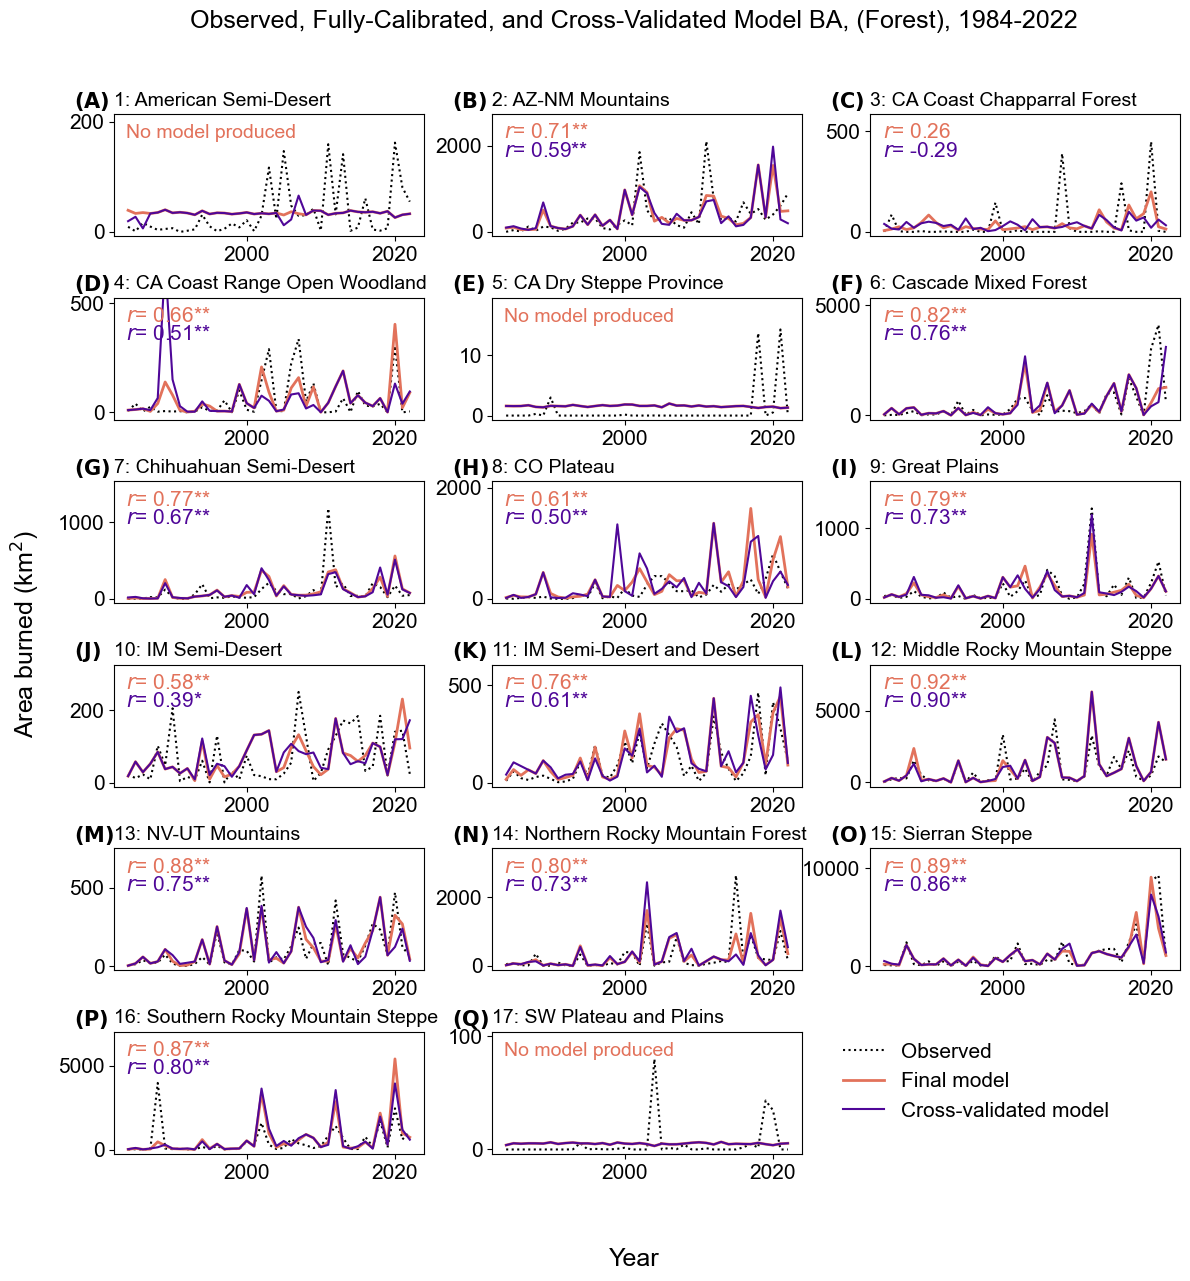

In [25]:
# forest figure of the r-values for each ecoprovince

years = np.arange(firstyear, finalyear+1)
fig, ax = plt.subplots(6,3, figsize=(13,13))
figrow = np.arange(0,6)
figcol = np.arange(0,3)
r_forfull = [] # store Pearson correlation
r_forCV = []

i = 0
j = 0
for thisrow in figrow:
    for thiscol in figcol:
        if i>=(len(dfnames)):
            break
        if (dfnames[i]=='allwestUS') or (dfnames[i]=='ecoprov3') or (dfnames[i]=='ecoprov6') or (dfnames[i]=='ecoprov18'):
            print(str(i)+' will be skipped')
            i+=1
        thisname = dfnames[i]
        tmptoplot = (10**BACVpredfor.filter(like=(thisname+"_"))).mean(axis=1)
        tmptoplot2 = (10**BAclimpredfor.filter(like=(thisname+"_"))).mean(axis=1)
        tmpobs = wumifor.iloc[:,i]
        tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
        tmptoplotlog = np.ma.masked_invalid(np.log10(tmptoplot)).filled(0)
        tmptoplot2log = np.ma.masked_invalid(np.log10(tmptoplot2)).filled(0)
        tmpr, tmpp = pearsonr(tmpobslog, tmptoplotlog)
        tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2log)
        ax[thisrow,thiscol].plot(years, tmpobs, ':', color='k', label='obs')
        ax[thisrow,thiscol].plot(years, (tmptoplot2), 
                                 color=colorobs, label='fullmodel',
                                linewidth=2)
        ax[thisrow,thiscol].plot(years, (tmptoplot), 
                                 color=colorCross, label='OOS pred',
                                linewidth=1.5)
        tmppformat = addSigMarker(tmpp)
        tmppformat2 = addSigMarker(tmpp2)
        ax[thisrow,thiscol].set_title(prov_label_names[j],loc='left',fontsize=14)
        
        r_forCV.append(tmpr)
        r_forfull.append(tmpr2)
        
        # set height
        tmpmax_val = np.array([tmptoplot2]+[tmpobs]).max()
        tmprounded_max = np.ceil(tmpmax_val / 5) * 5 
        current_min = ax[thisrow,thiscol].get_ylim()[0]
        #ax[thisrow,thiscol].set_xlim([1978,finalyear+5])
        ax[thisrow,thiscol].set_ylim([current_min,tmprounded_max*1.3])

        # no model produced for these ecoprovinces
        if j in [1-1,5-1,17-1]:
            ax[thisrow,thiscol].annotate('No model produced',(0.04,0.80),
                                         ha='left', c=colorobs, xycoords='axes fraction',
                                         fontsize=14)
        # if model exists, print r-values
        else:
            ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), 
                    (0.04,0.80), c=colorobs, xycoords='axes fraction' )
            ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), 
                    (0.04,0.65), c=colorCross, xycoords='axes fraction' )
        
        i+=1
        j+=1
fig.supylabel('Area burned (km$^2$)')
fig.supxlabel('Year')
fig.suptitle('Observed, Fully-Calibrated, and Cross-Validated Model BA, (Forest), '
             +str(firstyear)+'-'+str(finalyear))
fig.delaxes(ax[5,2])
fig.legend(['Observed', 'Final model', 'Cross-validated model'],
           frameon=False, bbox_to_anchor=(0.88,0.20))

k=0
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
# add figure labels
for thisrow in figrow:
    for thiscol in figcol:
        thisfiglabel = figlabels[k]
        ax[thisrow,thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), 
                                     c='k', xycoords='axes fraction')
        k+=1
        
plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.1, right=0.92, top=0.9, bottom=0.1)

plt.savefig(figfolder + 'Suppl_CrossValid_Ecoprov_Forest.png', bbox_inches="tight")

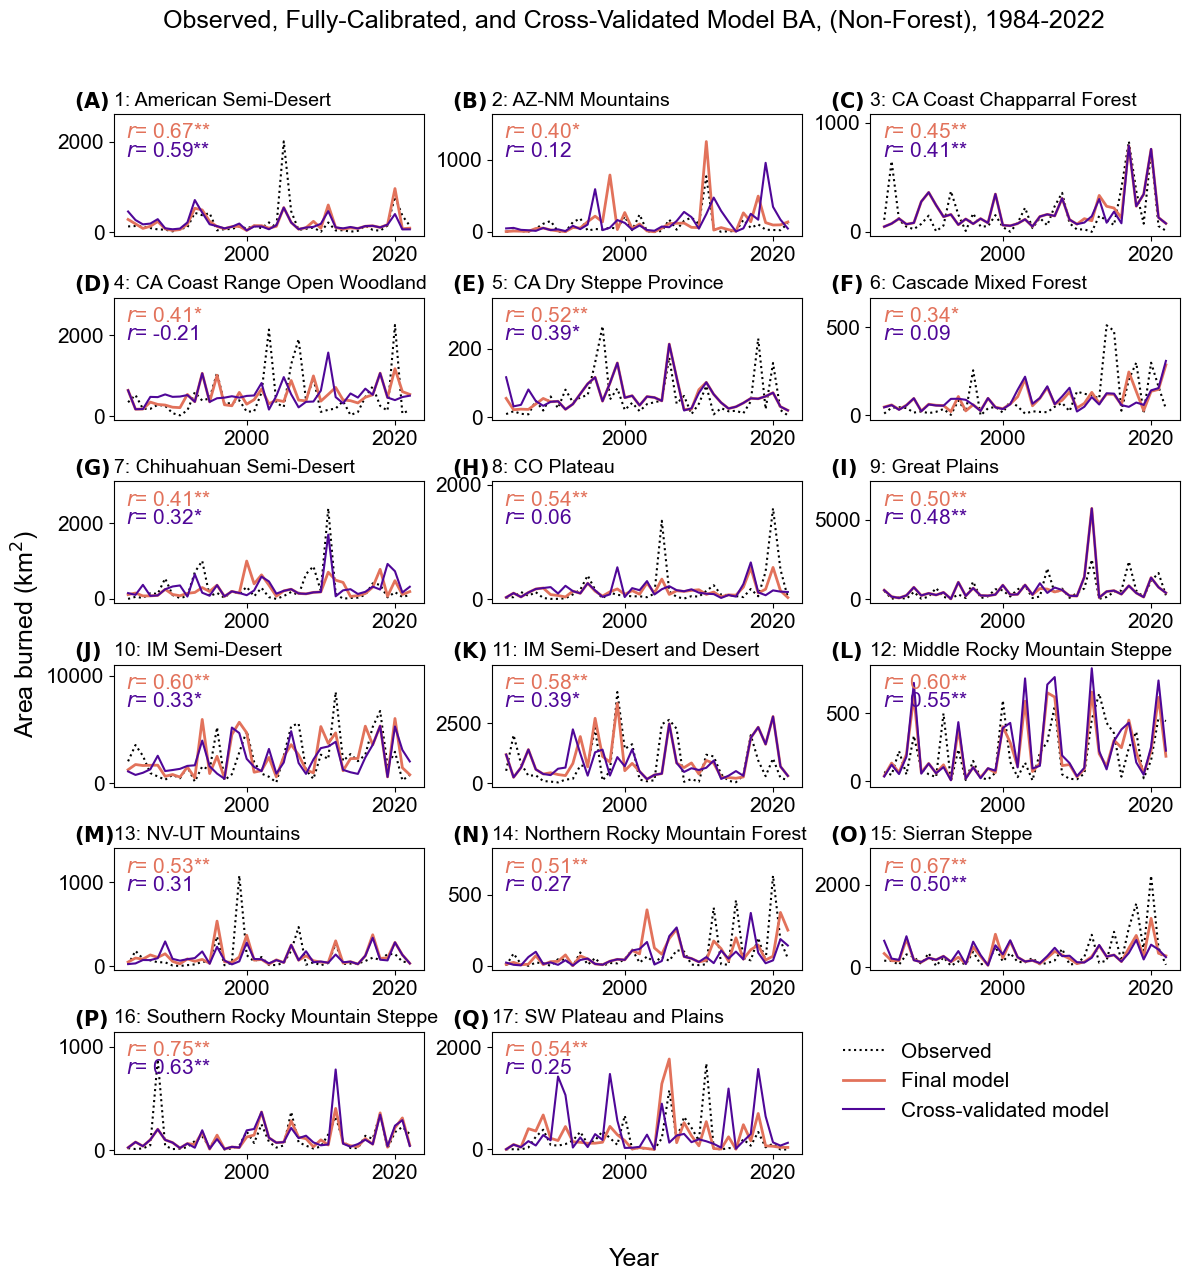

In [26]:
# nonforest figure of the r-values for each ecoprovince

years = np.arange(firstyear, finalyear+1)
fig, ax = plt.subplots(6,3, figsize=(13,13))
figrow = np.arange(0,6)
figcol = np.arange(0,3)
r_nonfull = [] # store Pearson correlation
r_nonCV = []

i = 0
j = 0
for thisrow in figrow:
    for thiscol in figcol:
        if i>=(len(dfnames)):
            break
        if (dfnames[i]=='allwestUS') or (dfnames[i]=='ecoprov3') or (dfnames[i]=='ecoprov6') or (dfnames[i]=='ecoprov18'):
            i+=1
        thisname = dfnames[i]
        tmptoplot = (10**BACVprednon.filter(like=(thisname+"_"))).mean(axis=1)
        tmptoplot2 = (10**BAclimprednon.filter(like=(thisname+"_"))).mean(axis=1)
        tmpobs = wuminon.iloc[:,i]
        tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
        tmpr, tmpp = pearsonr(tmpobslog, tmptoplot)
        tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2)
        ax[thisrow,thiscol].plot(years, tmpobs,':', color='k', label='obs')
        ax[thisrow,thiscol].plot(years, (tmptoplot2), 
                                 color=colorobs, label='fullmodel',
                                linewidth=2)
        ax[thisrow,thiscol].plot(years, (tmptoplot), 
                                 color=colorCross, label='OOS pred',
                                linewidth=1.5)
        ax[thisrow,thiscol].set_title(prov_label_names[j],loc='left',fontsize=14)
        
        tmppformat = addSigMarker(tmpp)
        tmppformat2 = addSigMarker(tmpp2)
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), (0.04,0.80), 
                c=colorobs, xycoords='axes fraction' )
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), (0.04,0.65), 
                c=colorCross, xycoords='axes fraction' )
        r_nonCV.append(tmpr)
        r_nonfull.append(tmpr2)
        # set height
        tmpmax_val = np.array([tmptoplot2]+[tmpobs]).max()
        tmprounded_max = np.ceil(tmpmax_val / 5) * 5 
        current_min = ax[thisrow,thiscol].get_ylim()[0]
        #ax[thisrow,thiscol].set_xlim([1978,finalyear+5])
        ax[thisrow,thiscol].set_ylim([current_min,tmprounded_max*1.3])

        
        i+=1
        j+=1
fig.supylabel('Area burned (km$^2$)')
fig.supxlabel('Year')
fig.suptitle('Observed, Fully-Calibrated, and Cross-Validated Model BA, (Non-Forest), '
             +str(firstyear)+'-'+str(finalyear))
fig.delaxes(ax[5,2])
fig.legend(['Observed','Final model', 'Cross-validated model'],
           frameon=False, bbox_to_anchor=(0.88,0.20))

k=0
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
# add figure labels
for thisrow in figrow:
    for thiscol in figcol:
        thisfiglabel = figlabels[k]
        ax[thisrow,thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), c='k', xycoords='axes fraction')
        k+=1

plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.1, right=0.92, top=0.9, bottom=0.1)

        
fig.savefig(figfolder + 'Suppl_CrossValid_Ecoprov_NonForest.png', bbox_inches="tight")

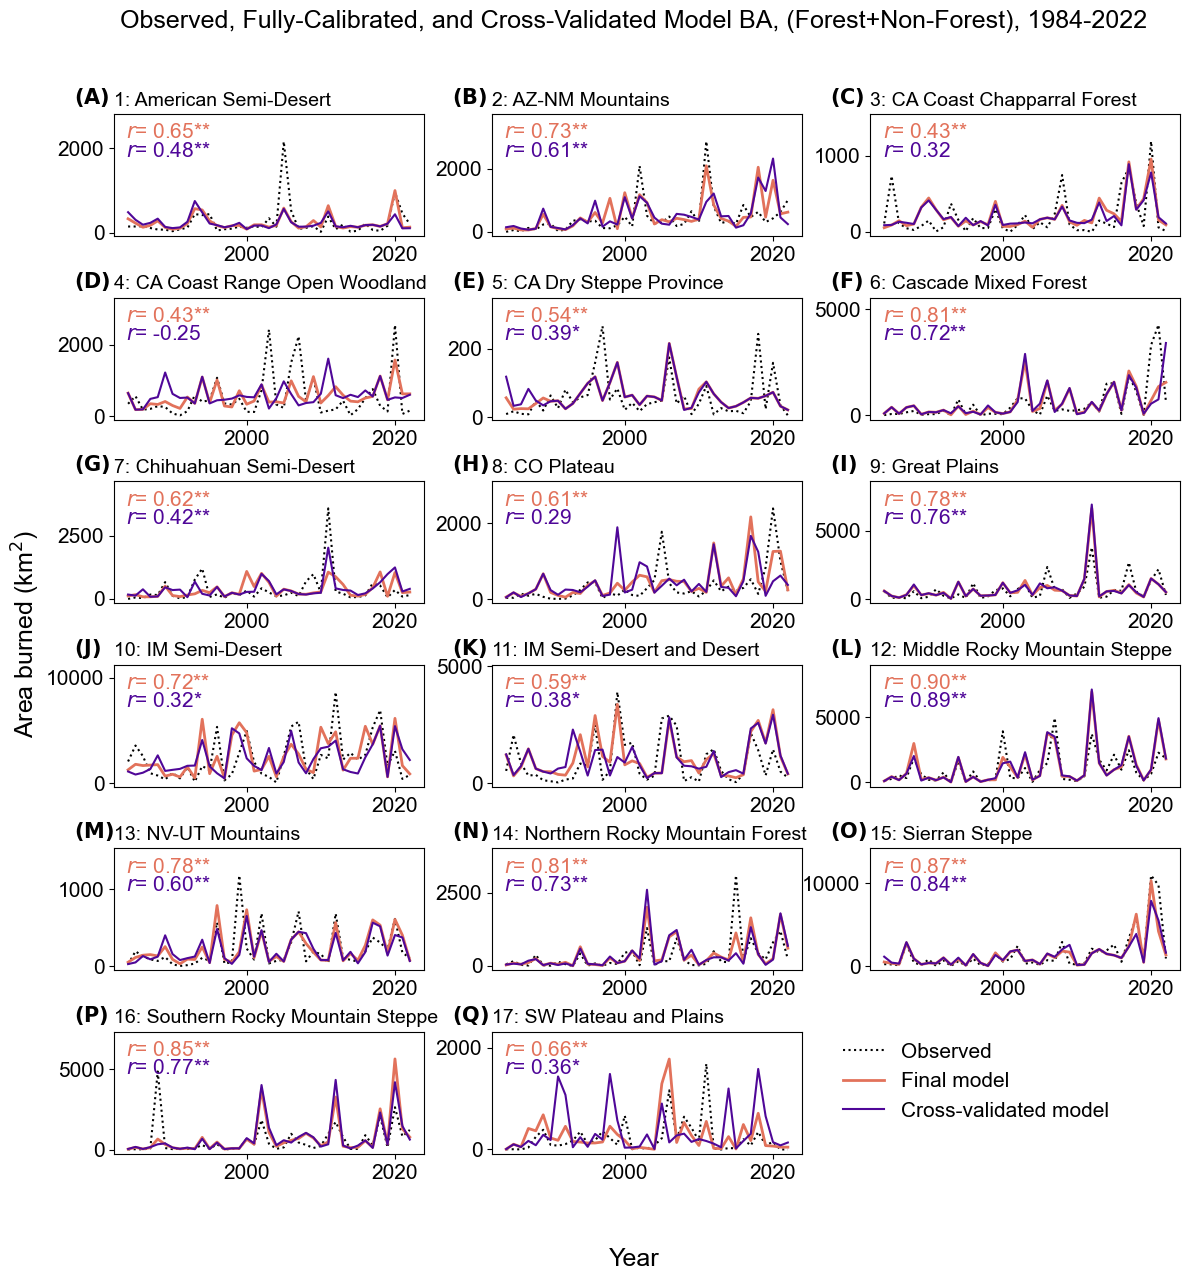

In [27]:
# ALL=forest+nonforest figure of the r-values for each ecoprovince

years = np.arange(firstyear, finalyear+1)
fig, ax = plt.subplots(6,3, figsize=(13,13))
figrow = np.arange(0,6)
figcol = np.arange(0,3)
r_allfull = [] # store Pearson correlation
r_allCV = []

i = 0
j = 0
for thisrow in figrow:
    for thiscol in figcol:
        if i>=(len(dfnames)):
            break
        if (dfnames[i]=='allwestUS') or (dfnames[i]=='ecoprov3') or (dfnames[i]=='ecoprov6') or (dfnames[i]=='ecoprov18'):
            i+=1
        thisname = dfnames[i]
        tmptoplot = (10**BACVpredall.filter(like=(thisname+"_"))).mean(axis=1)
        tmptoplot2 = (10**BAclimpredall.filter(like=(thisname+"_"))).mean(axis=1)
        tmptoplotlog = np.ma.masked_invalid(np.log10(tmptoplot)).filled(0)
        tmptoplot2log = np.ma.masked_invalid(np.log10(tmptoplot2)).filled(0)
        tmpobs = wuminon.iloc[:,i]+wumifor.iloc[:,i]
        tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
        tmpr, tmpp = pearsonr(tmpobslog, tmptoplotlog)
        tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2log)
        ax[thisrow,thiscol].plot(years, tmpobs,':', color='k', label='obs')
        ax[thisrow,thiscol].plot(years, tmptoplot2, 
                                 color=colorobs, label='fullmodel',
                                linewidth=2)
        ax[thisrow,thiscol].plot(years, tmptoplot, 
                                 color=colorCross, label='OOS pred',
                                linewidth=1.5)
        ax[thisrow,thiscol].set_title(prov_label_names[j],loc='left',fontsize=14)
        
        tmppformat = addSigMarker(tmpp)
        tmppformat2 = addSigMarker(tmpp2)
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), (0.04,0.80), 
                c=colorobs, xycoords='axes fraction' )
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), (0.04,0.65), 
                c=colorCross, xycoords='axes fraction' )
        r_allCV.append(tmpr)
        r_allfull.append(tmpr2)

        # set height
        tmpmax_val = np.array([tmptoplot2]+[tmpobs]).max()
        tmprounded_max = np.ceil(tmpmax_val / 5) * 5 
        current_min = ax[thisrow,thiscol].get_ylim()[0]
        #ax[thisrow,thiscol].set_xlim([1978,finalyear+5])
        ax[thisrow,thiscol].set_ylim([current_min,tmprounded_max*1.3])
        i+=1
        j+=1
fig.supylabel('Area burned (km$^2$)')
fig.supxlabel('Year')
fig.suptitle('Observed, Fully-Calibrated, and Cross-Validated Model BA, (Forest+Non-Forest), '
             +str(firstyear)+'-'+str(finalyear))
fig.delaxes(ax[5,2])
fig.legend(['Observed','Final model','Cross-validated model'],
           frameon=False, bbox_to_anchor=(0.88,0.20))

k=0
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
# add figure labels
for thisrow in figrow:
    for thiscol in figcol:
        thisfiglabel = figlabels[k]
        ax[thisrow,thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.08), c='k', xycoords='axes fraction')
        k+=1

plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.1, right=0.92, top=0.9, bottom=0.1)

        
fig.savefig(figfolder + 'Suppl_CrossValid_Ecoprov-Forest+NonForestSum.png', bbox_inches="tight")

## Forest + Non-forest (added confidence intervals too)

In [28]:
# script for getting all slopes from 500-member ensemble
def ensemble_trends(df, years):
    slopes = []
    intercepts = []
    for col in df.columns:
        y = np.log10(df[col])
        fit = theilslopes(
            y,x=years,
            method='joint')
        slopes.append(fit.slope)
        intercepts.append(fit.intercept)
    return np.array(slopes), np.array(intercepts)

In [29]:
# calculate all possible trendline VALUES based on 500-member ensemble trendlines
# this is for all years, but in prep to get first and last years

# GET ALL THEIL SEN TRENDLINES
# USE THEM TO GET 95TH CONFIDENCE INTERVAL (6/18/2026)
xyears = np.arange(firstyear,finalyear+1,1)

ecoregname = 'allwestUS'
tmpBAall = (10**BAclimpredall.filter(like=ecoregname))
tmpBAfor = (10**BAclimpredfor.filter(like=ecoregname))
tmpBAnon = (10**BAclimprednon.filter(like=ecoregname))
tmpBAall_CV = (10**BACVpredall.filter(like=ecoregname))
tmpBAfor_CV = (10**BACVpredfor.filter(like=ecoregname))
tmpBAnon_CV = (10**BACVprednon.filter(like=ecoregname))

# ALL POSSIBLE THEIL SEN TRENDLINES
slopes_all, intercepts_all = ensemble_trends(
    tmpBAall, xyears)
slopes_for, intercepts_for = ensemble_trends(
    tmpBAfor, xyears)
slopes_non, intercepts_non = ensemble_trends(
    tmpBAnon, xyears)
slopes_all_CV, intercepts_all_CV = ensemble_trends(
    tmpBAall_CV, xyears)
slopes_for_CV, intercepts_for_CV = ensemble_trends(
    tmpBAfor_CV, xyears)
slopes_non_CV, intercepts_non_CV = ensemble_trends(
    tmpBAnon_CV, xyears)

# calculate all possible trendline VALUES based on 500-member ensemble trendlines
# this is for all years, but in prep to get first and last years

# shape: (500, nyears)
tmpBAall_trendspread = 10**(
    slopes_all[:, None] * xyears[None, :] + intercepts_all[:, None])
tmpBAfor_trendspread = 10**(
    slopes_for[:, None] * xyears[None, :] + intercepts_for[:, None])
tmpBAnon_trendspread = 10**(
    slopes_non[:, None] * xyears[None, :] + intercepts_non[:, None])
tmpBAall_trendspread_CV = 10**(
    slopes_all_CV[:, None] * xyears[None, :] + intercepts_all_CV[:, None])
tmpBAfor_trendspread_CV = 10**(
    slopes_for_CV[:, None] * xyears[None, :] + intercepts_for_CV[:, None])
tmpBAnon_trendspread_CV = 10**(
    slopes_non_CV[:, None] * xyears[None, :] + intercepts_non_CV[:, None])

# calculate 95th percentile confidence interval for each year

all_lo = np.percentile(tmpBAall_trendspread, 2.5, axis=0)
all_hi = np.percentile(tmpBAall_trendspread, 97.5, axis=0)

for_lo = np.percentile(tmpBAfor_trendspread, 2.5, axis=0)
for_hi = np.percentile(tmpBAfor_trendspread, 97.5, axis=0)

non_lo = np.percentile(tmpBAnon_trendspread, 2.5, axis=0)
non_hi = np.percentile(tmpBAnon_trendspread, 97.5, axis=0)

all_lo_CV = np.percentile(tmpBAall_trendspread_CV, 2.5, axis=0)
all_hi_CV = np.percentile(tmpBAall_trendspread_CV, 97.5, axis=0)

for_lo_CV = np.percentile(tmpBAfor_trendspread_CV, 2.5, axis=0)
for_hi_CV = np.percentile(tmpBAfor_trendspread_CV, 97.5, axis=0)

non_lo_CV = np.percentile(tmpBAnon_trendspread_CV, 2.5, axis=0)
non_hi_CV = np.percentile(tmpBAnon_trendspread_CV, 97.5, axis=0)

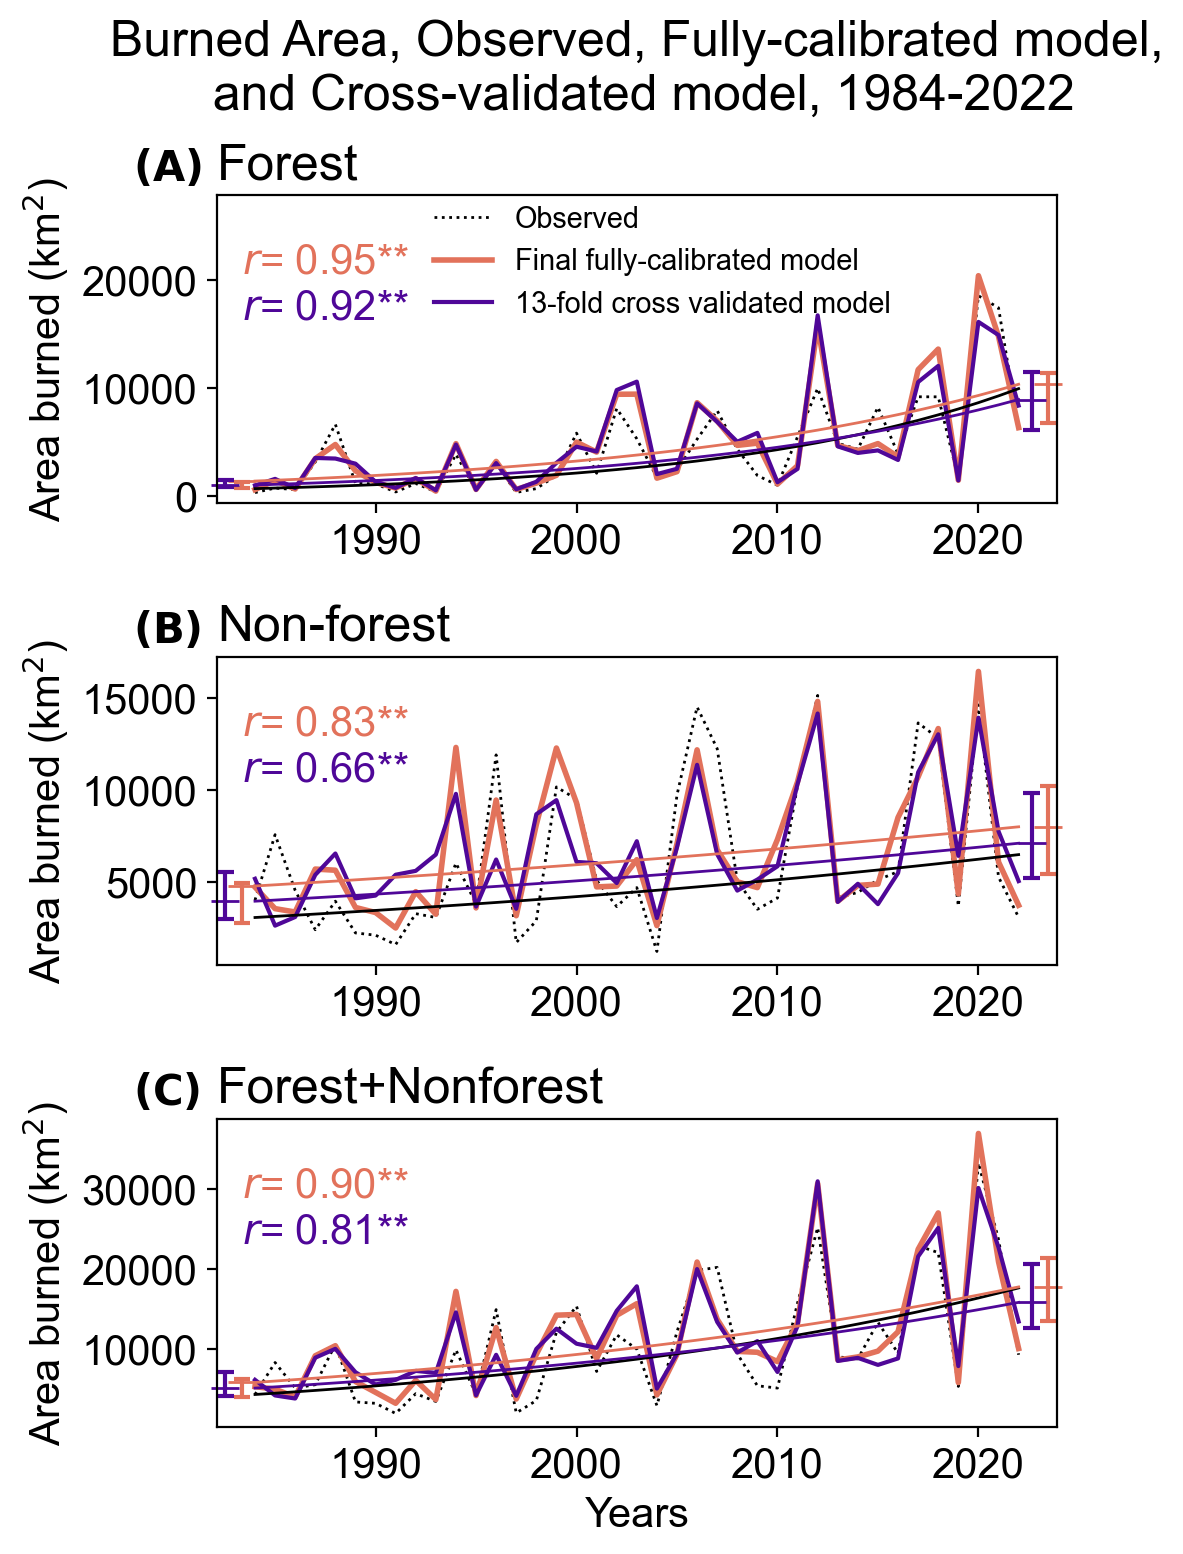

In [30]:
# final years
xyears = np.arange(firstyear,finalyear+1,1)

thisname = 'allwestUS'
tmpCVall = BACVpredall.filter(like=(thisname+'_'))
tmpCVfor = BACVpredfor.filter(like=(thisname+'_'))
tmpCVnon = BACVprednon.filter(like=(thisname+'_'))
tmpclimall = BAclimpredall.filter(like=(thisname+'_'))
tmpclimfor = BAclimpredfor.filter(like=(thisname+'_'))
tmpclimnon = BAclimprednon.filter(like=(thisname+'_'))

# plot in order: FOREST, NON-FOREST, ALL
sumswumi = [wumifor.loc[:,'0'], wuminon.loc[:,'0'], wumi.loc[:,'0']]
sumsBA = [tmpCVfor, tmpCVnon, tmpCVall] # this is log10
sumsBA2 = [tmpclimfor, tmpclimnon, tmpclimall] # this is log10
# trendline confidence intervals for modeled runs
trendBA_hi = [for_hi, non_hi, all_hi]
trendBA_lo = [for_lo, non_lo, all_lo]
trendBA_lo_CV = [for_lo_CV, non_lo_CV, all_lo_CV]
trendBA_hi_CV = [for_hi_CV, non_hi_CV, all_hi_CV]

# make plot
fig, ax = plt.subplots(3,1, figsize=(5,8), dpi=200)

fig.suptitle('Burned Area, Observed, Fully-calibrated model,\n and Cross-validated model, '
             +str(firstyear)+'-'+str(finalyear))

# line of best fit
tmpm = np.zeros(3)
tmpmBA = np.zeros(3)
tmpmBA2 = np.zeros(3)
tmpb = np.zeros(3)
tmpbBA = np.zeros(3)
tmpbBA2 = np.zeros(3)

for i in np.arange(0,3):

    # unlog the modeled BA
    toplot1 = (10**sumsBA[i]).mean(axis=1)
    toplot2 = (10**sumsBA2[i]).mean(axis=1)
    
    # wumi lines of best fit
    tmpbestfit = theilslopes(np.log10(sumswumi[i]), x=xyears, method='joint') # regression
    tmpm[i] = tmpbestfit.slope
    tmpb[i] = tmpbestfit.intercept
    # BA model lines of best fit
    tmpbestfit = theilslopes(np.log10(toplot1), x=xyears, method='joint') # regression
    tmpmBA[i] = tmpbestfit.slope
    tmpbBA[i] = tmpbestfit.intercept
    # detrended BA model lines of best fit
    tmpbestfit = theilslopes(np.log10(toplot2), x=xyears, method='joint') # regression
    tmpmBA2[i] = tmpbestfit.slope
    tmpbBA2[i] = tmpbestfit.intercept

    
    
    ax[i].plot(sumswumi[i], ':',label='Observed', c='k', linewidth=1)
    ax[i].plot(xyears, toplot2, label='Full model', c=colorobs,
              linewidth=2)
    ax[i].plot(xyears, toplot1, label='From cross-validated model', c=colorCross,
              linewidth=1.5)
    ax[i].set_ylabel('Area burned (km$^2$)')
    tmpr, tmpp = pearsonr(np.log10(sumswumi[i]), np.log10(toplot1))
    tmpr2, tmpp2 = pearsonr(np.log10(sumswumi[i]), np.log10(toplot2))

    # plot lines of best fit
    ax[i].plot(xyears, 10**(tmpm[i]*xyears+tmpb[i]), 
               linewidth=1, c='k', zorder=3)
    ax[i].plot(xyears, 10**(tmpmBA[i]*xyears+tmpbBA[i]), 
               linewidth=1,c=colorobs, zorder=3)
    ax[i].plot(xyears, 10**(tmpmBA2[i]*xyears+tmpbBA2[i]), 
               linewidth=1,  c=colorCross, zorder=3)

    # add r-value to plot
    tmppformat = addSigMarker(tmpp)
    tmppformat2 = addSigMarker(tmpp2)
    ax[i].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), (0.03,0.75), 
                c=colorobs, xycoords='axes fraction' )
    ax[i].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), (0.03,0.60), 
                c=colorCross, xycoords='axes fraction' )


fig.legend(['Observed','Final fully-calibrated model',
           '13-fold cross validated model'], frameon=False,
           bbox_to_anchor=(0.78,0.88), fontsize='x-small',)
ax[2].set_xlabel('Years')
ax[2].set_title('Forest+Nonforest', loc='left')
ax[0].set_title('Forest', loc='left')
ax[1].set_title('Non-forest', loc='left')
#ax[2].annotate('All',(0.06,0.85), c='#000', xycoords='axes fraction' )
#ax[0].annotate('Forest',(0.06,0.85), c='#000', xycoords='axes fraction' )
#ax[1].annotate('Non-forest',(0.06,0.85), c='#000', xycoords='axes fraction' )

# set height
current_min, current_max = ax[0].get_ylim()
ax[0].set_ylim([current_min,current_max*1.3])
plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.08, right=0.92, top=0.87, bottom=0.1)

for i in np.arange(0,3):
    # TRENDLINE UNCERTAINTY WHISKERS (errorbars for 95th percentile confidence range)
    # trendlines already plotted above
    fit_obs = 10**(tmpmBA[i] * xyears + tmpbBA[i])
    fit_dt  = 10**(tmpmBA2[i] * xyears + tmpbBA2[i])
    
    # x positions in axes coordinates
    xleft_obs  = 0.03
    xleft_dt   = 0.01
    xright_obs = 0.99
    xright_dt  = 0.97
    capwidth = 0.010
    
    trans = ax[i].get_yaxis_transform()
    
    # --------------------------------
    # OBSERVED-CLIMATE TRENDLINE
    # left endpoint
    ym = fit_obs[0]
    y0 = trendBA_lo[i][0]
    y1 = trendBA_hi[i][0]
    
    ax[i].vlines(
        xleft_obs, y0, y1, color=colorobs, lw=1.5,
        transform=trans, clip_on=False
    )
    ax[i].hlines(
        [y0, y1],
        xleft_obs-capwidth,
        xleft_obs+capwidth, color=colorobs, lw=1.5,
        transform=trans, clip_on=False
    )
    ax[i].plot(
        xleft_obs, ym,
        marker='_', markersize=10, color=colorobs,
        transform=trans, clip_on=False
    )
    # right endpoint
    ym = fit_obs[-1]
    y0 = trendBA_lo[i][-1]
    y1 = trendBA_hi[i][-1]
    
    ax[i].vlines(
        xright_obs, y0, y1, color=colorobs, lw=1.5,
        transform=trans, clip_on=False)
    ax[i].hlines(
        [y0, y1],
        xright_obs-capwidth,
        xright_obs+capwidth, color=colorobs, lw=1.5,
        transform=trans, clip_on=False)
    ax[i].plot(
        xright_obs, ym,
        marker='_', markersize=10, color=colorobs,
        transform=trans, clip_on=False)
    # --------------------------
    # DETRENDED-SST TRENDLINE
    
    # left endpoint
    ym = fit_dt[0]
    y0 = trendBA_lo_CV[i][0]
    y1 = trendBA_hi_CV[i][0]
    
    ax[i].vlines(
        xleft_dt, y0, y1, color=colorCross, lw=1.5,
        transform=trans, clip_on=False)
    ax[i].hlines(
        [y0, y1],
        xleft_dt-capwidth,
        xleft_dt+capwidth, color=colorCross, lw=1.5,
        transform=trans, clip_on=False)
    ax[i].plot(
        xleft_dt, ym,
        marker='_', markersize=10, color=colorCross,
        transform=trans, clip_on=False)
    # right endpoint
    ym = fit_dt[-1]
    y0 = trendBA_lo_CV[i][-1]
    y1 = trendBA_hi_CV[i][-1]
    
    ax[i].vlines(
        xright_dt, y0, y1,
        color=colorCross, lw=1.5,
        transform=trans, clip_on=False)
    ax[i].hlines(
        [y0, y1],
        xright_dt-capwidth,
        xright_dt+capwidth, color=colorCross, lw=1.5,
        transform=trans, clip_on=False)
    ax[i].plot(
        xright_dt, ym,
        marker='_', markersize=10, color=colorCross,
        transform=trans, clip_on=False)


k=0
figlabels = [chr(i) for i in range(65, 65 + 3)]
# add figure labels
for i in np.arange(3):
    thisfiglabel = figlabels[k]
    ax[i].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.1,1.05), c='k', xycoords='axes fraction')
    k+=1
fig.patch.set_alpha(0)

        
fig.savefig(figfolder + 'Suppl_CrossValid_ModelAllSums.png', bbox_inches="tight")

# maps of correlation values

(6/25/2024)

**Comment from Park on draft v2 of paper, May 14, 2024:** I also would like to suggest more SI figs. This section would be aided by some correlation maps. I suggest one figure with a pair of maps showing 
1. fully-calibrated correlation and cross-validated correlation by ecoprovince (below), and
2. then another pair of maps that is the same but breaks out forest and non-forest. (below)
3. I also suggest another set of regional time series plots that represents total area burned (forest + non-forest). (done, above)

In [31]:
# import ecoprovinces first, then use them to plot
# mapping
from customconfig import *

import geopandas as gpd
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import Colorbar
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, LAND
from shapely.geometry import Polygon
from shapely.geometry import JOIN_STYLE
from shapely.ops import unary_union
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from itertools import compress
import pandas as pd
from scipy.stats import pearsonr
import colorcet # more colormaps


# customize seasons for climate variables

years = np.arange(firstyear, finalyear+1)

# importing data string
# climindname is not used except for saving to a folder
# Read the climate index from the .txt file
with open('0_climindname.txt', 'r') as f:
    climindname = f.read().strip()
print(climindname +' will be used for the SST gradient')
#data_string = 'data\\'
data_string = 'data//'
#model_string = 'model\\'+climindname+'\\'
model_string = 'model//'+climindname+'//'
#predict_string = 'predicted\\'+climindname+'\\'
predict_string = 'predicted//'+climindname+'//'

patch125-155_nino3-34 will be used for the SST gradient


In [32]:
# skip analysis for these ecoprovinces for low fire occurrence
# create filter for westUS + ecoprovs
df_filter = np.ones(len(dfnames))
dfnames_filter = ['allwestUS', 'ecoprov3', 'ecoprov6', 'ecoprov18']
for thisname in dfnames_filter:
    df_filter[dfnames.index(thisname)] = 0 # filter out this ecoregion
# filter arrays
dfnames = list(compress(dfnames, df_filter))

# create filter for ecoprovs
df_filternum = np.ones(len(province_num[1:]))
dfnum_filter = np.array([3,6,18])
for thisnum in dfnum_filter:
    df_filternum[province_num[1:]==thisnum] = 0 # filter out this ecoregion
# filter arrays
province_names = list(compress(province_names, df_filternum))
prov_abbr_names = list(compress(prov_abbr_names, df_filternum))
dfnum = np.array(list(compress(province_num[1:], df_filternum)))

In [33]:
# translate years into dates
from customconfig import *
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

#ecoreg_string = directory + '12km\\landcover\\Ecoregions_EPA\\bailey_ecoprovince.nc'
ecoreg_string = directory + '12km//landcover//Ecoregions_EPA//bailey_ecoprovince.nc'
ecoreg = xr.open_dataset(ecoreg_string, engine='netcdf4')
print(ecoreg.bailey_ecoprovince.province.legend)
ecoreg = ecoreg.bailey_ecoprovince

# import western US study area
#westUS_string = directory + '12km\\study_area\\westUS.nc'
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# add in entire western US
#ecoreg = xr.concat([westUS, ecoreg.bailey_ecoprovince], dim='province')
# remove the ecoregion that does not overlap with the western US
ecoreg = ecoreg.sel(province=province_num[1:])
ecoreg = westUS*ecoreg # crop to western US only

1: American Semi-Desert and Desert Province, 2: Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province, 3: Black Hills Coniferous Forest Province, 4: California Coastal Chapparral Forest and Shrub Province, 5: California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province, 6: California Coastal Steppe-Mixed Forest-Redwood Forest Province, 7: California Dry Steppe Province, 8: Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province, 9: Chihuahuan Semi-Desert Province, 10: Colorado Plateau Semi-Desert Province, 11: Great Plains Steppe Province, 12: Great Plains-Palouse Dry Steppe Province, 13: Intermountain Semi-Desert Province, 14: Intermountain Semi-Desert and Desert Province, 15: Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province, 16: Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province, 17: Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province, 18: Pacific 

## for Ecoprovince map

* `Becoprov` to plot shapefiles of Bailey's Ecoprovinces on a map so they can be colored according to data.
    * The CRS used is defined within the shapefile, so **no need to call `transform` when plotting**
* `ecoreg` to plot xarray-based gridded data of Bailey's ecoprovinces on a figure.
    * Use CRS `ccrs.PlateCarree()` when plotting

In [34]:
# import Bailey's Ecoregions
Bailey_string = '1km//landcover//ecoregions//shapefiles//bailey//eco-us-shp-GCS//eco-us-shp-GCS.shp'
Becoreg = gpd.read_file(directory + Bailey_string)

# projection info from file
Bailey_crs = Becoreg.crs
# projection info from website
#EPA_crs2 = ccrs.LambertAzimuthalEqualArea(central_longitude=-100, central_latitude=45, 
#                                         false_easting=0.0, false_northing=0.0, globe=None)

# get shapefile of just western US from US Census Bureau
# for some reason it includes Hawaii and Alaska
#Census_string = directory + 'Census Bureau\\Cartographic Boundary Files_Regions\\cb_2018_us_region_500k.shp'
Census_string = 'Census Bureau//Cartographic Boundary Files_Regions//cb_2018_us_region_500k.shp'
wUSregion = gpd.read_file(directory + Census_string)
wUSregion = wUSregion[wUSregion.NAME=='West']
# remove HI and AK
extentpoly = Polygon([(-130,30), (-130,50), (-100,50),(-100,30)])
poly_gdf = gpd.GeoDataFrame(geometry=[extentpoly], crs=ccrs.PlateCarree())
wUSregion = wUSregion.clip(extentpoly)

wUSregion = wUSregion.to_crs(Bailey_crs) # transform projection

# clip the ecoregions to just western US
Becoreg = gpd.clip(Becoreg, wUSregion)
# sort to the same order as data
Becoreg = Becoreg.set_index('PROVINCE')
Becoreg = Becoreg.loc[province_names]

# iterate through ecoregions and merge into ecoprovinces
# group the data by ecoregion
Becoprov = gpd.GeoDataFrame(columns=['PROVINCE','NUMBER','geometry'], geometry='geometry')
gbecoreg = Becoreg.groupby('PROVINCE')
i = 0 # start counter
eps = 0.001 # define buffer
# iterate through each province and MERGE the ecoregions
for thisname, thisgroup in gbecoreg:
    thisgeometry = thisgroup.geometry.to_crs('epsg:5070') # set CRS with m as unit
    thisgeometry = thisgeometry.buffer(eps, 1, join_style=JOIN_STYLE.mitre) # add buffer
    thisgeometry = unary_union(thisgeometry).buffer(-eps, 1, join_style=JOIN_STYLE.mitre) # merge, then remove buffer
    thisgeometry = gpd.GeoSeries(thisgeometry).set_crs('epsg:5070').to_crs('epsg:4326') # set CRS with degrees
    #thisgeometry = gpd.GeoSeries(unary_union(thisgroup.geometry))
    thisprovince = gpd.GeoDataFrame(data={'PROVINCE': thisname, 
                                          'NUMBER': province_num[i+1], 
                                          'geometry': thisgeometry}, geometry='geometry')
    # append to create ecoprovince geodataframe
    Becoprov = gpd.GeoDataFrame(pd.concat([Becoprov, thisprovince], ignore_index=True))
    i+=1

# Becoprov is now a geodataframe I can use, with SHAPEFILES of provinces.

## import forest and nonforest area
* `westUS` is xarray-based gridded data of the western US region.
* `forest` is xarray-based forest gridded data, within western US.
* `nonforest` is xarray-based nonforest gridded data within western US.
* `ecoreg` is xarray-based ecoprovinces
* `ecoregfor` is xarray-based ecoprovinces, forest area only
* `ecoregnon` is xarray-based ecoprovinces, nonforest area only

In [35]:
# import western US study area
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
forest_string = directory + '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)
# add province as dimension to the westUS, to combine with ecoregions
westUS = westUS.expand_dims({'province':[0]})

In [36]:
# import fire data, both modis and wumi databases
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

In [37]:
# import the exported cross-validation
filename = predict_string + 'BurnArea_'

BACVpredall = pd.read_csv(filename+'crossvalid_all'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BACVpredfor = pd.read_csv(filename+'crossvalid_for'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BACVprednon = pd.read_csv(filename+'crossvalid_non'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [38]:
# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
BAclimpredall = pd.read_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [39]:
# divide forest and nonforest into ecoprovinces

ecoregfor = [] # storage
ecoregnon = []

# get forest and nonforest pixels only where greater than .5
for thisregnum in dfnum:
    tmpfor = (forest.where(forest>.50))*ecoreg.sel(province=thisregnum)
    tmpnon = (nonforest.where(nonforest>.50))*ecoreg.sel(province=thisregnum)
    ecoregfor.append(tmpfor.to_numpy())
    ecoregnon.append(tmpnon.to_numpy())

# create xarray out of the data
ecoregfor = xr.DataArray(ecoregfor, coords={'province':dfnum,
                                'Y':forest.Y, 'X':forest.X})
ecoregnon = xr.DataArray(ecoregnon, coords={'province':dfnum,
                                'Y':forest.Y, 'X':forest.X})

In [40]:
# skip analysis for these ecoprovinces for low fire occurrence
# create filter for westUS + ecoprovs
df_filter = np.ones(len(dfnames))
dfnames_filter = ['allwestUS', 'ecoprov3', 'ecoprov6', 'ecoprov18']
for thisname in dfnames_filter:
    df_filter[dfnames.index(thisname)] = 0 # filter out this ecoregion
# filter arrays
dfnames = list(compress(dfnames, df_filter))


In [41]:
# get correlation values (log(observed), log(modeled))
r_forCV = [] # storage
r_forfull = []
r_allCV = []
r_allfull = []
r_nonCV = []
r_nonfull = []

for i, thisname in enumerate(dfnames):
    j = dfnum[i]
    # ALL
    tmptoplot = (10**BACVpredall.filter(like=(thisname+"_"))).mean(axis=1)
    tmptoplot2 = (10**BAclimpredall.filter(like=(thisname+"_"))).mean(axis=1)
    tmpobs = wuminon.loc[:,str(j)] + wumifor.loc[:,str(j)] # sum for 'all'
    tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
    tmptoplotlog = np.ma.masked_invalid(np.log10(tmptoplot)).filled(0)
    tmptoplot2log = np.ma.masked_invalid(np.log10(tmptoplot2)).filled(0)
    tmpr, tmpp = pearsonr(tmpobslog, tmptoplotlog)
    tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2log)
    r_allCV.append(tmpr)
    r_allfull.append(tmpr2)
    
    # FOREST
    tmptoplot = (10**BACVpredfor.filter(like=(thisname+"_"))).mean(axis=1)
    tmptoplot2 = (10**BAclimpredfor.filter(like=(thisname+"_"))).mean(axis=1)
    tmpobs = wumifor.loc[:,str(j)]
    tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
    tmptoplotlog = np.ma.masked_invalid(np.log10(tmptoplot)).filled(0)
    tmptoplot2log = np.ma.masked_invalid(np.log10(tmptoplot2)).filled(0)
    tmpr, tmpp = pearsonr(tmpobslog, tmptoplotlog)
    tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2log)
    r_forCV.append(tmpr)
    r_forfull.append(tmpr2)

    # NON-FOREST
    tmptoplot = (10**BACVprednon.filter(like=(thisname+"_"))).mean(axis=1)
    tmptoplot2 = (10**BAclimprednon.filter(like=(thisname+"_"))).mean(axis=1)
    tmpobs = wuminon.loc[:,str(j)]
    tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
    tmptoplotlog = np.ma.masked_invalid(np.log10(tmptoplot)).filled(0)
    tmptoplot2log = np.ma.masked_invalid(np.log10(tmptoplot2)).filled(0)
    tmpr, tmpp = pearsonr(tmpobslog, tmptoplotlog)
    tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2log)
    r_nonCV.append(tmpr)
    r_nonfull.append(tmpr2)


Forest Min -0.3756855730788904
Forest Max 0.9178289194550782


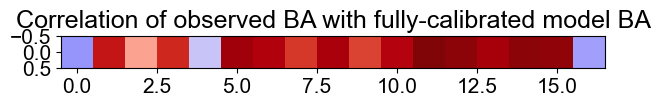

In [42]:
# Correlation for one to get colorbar
# gonna use r_forfull since I think the correlations are highest
# customize colorbar and color
cmapcolor = 'cet_CET_D1A'
cbarmin = -1 # set colorbar vmin and vmax
cbarmax = 1

# check out colorbar
image_corrfor = np.expand_dims(r_forfull, axis=0)
fig, ax = plt.subplots()
corrbar0 = ax.imshow(image_corrfor, cmap=cmapcolor, vmin=cbarmin, vmax=cbarmax)
ax.set_title('Correlation of observed BA with fully-calibrated model BA')

print('Forest Min', np.min(r_forfull))
print('Forest Max', np.max(r_forfull))

fig.tight_layout()

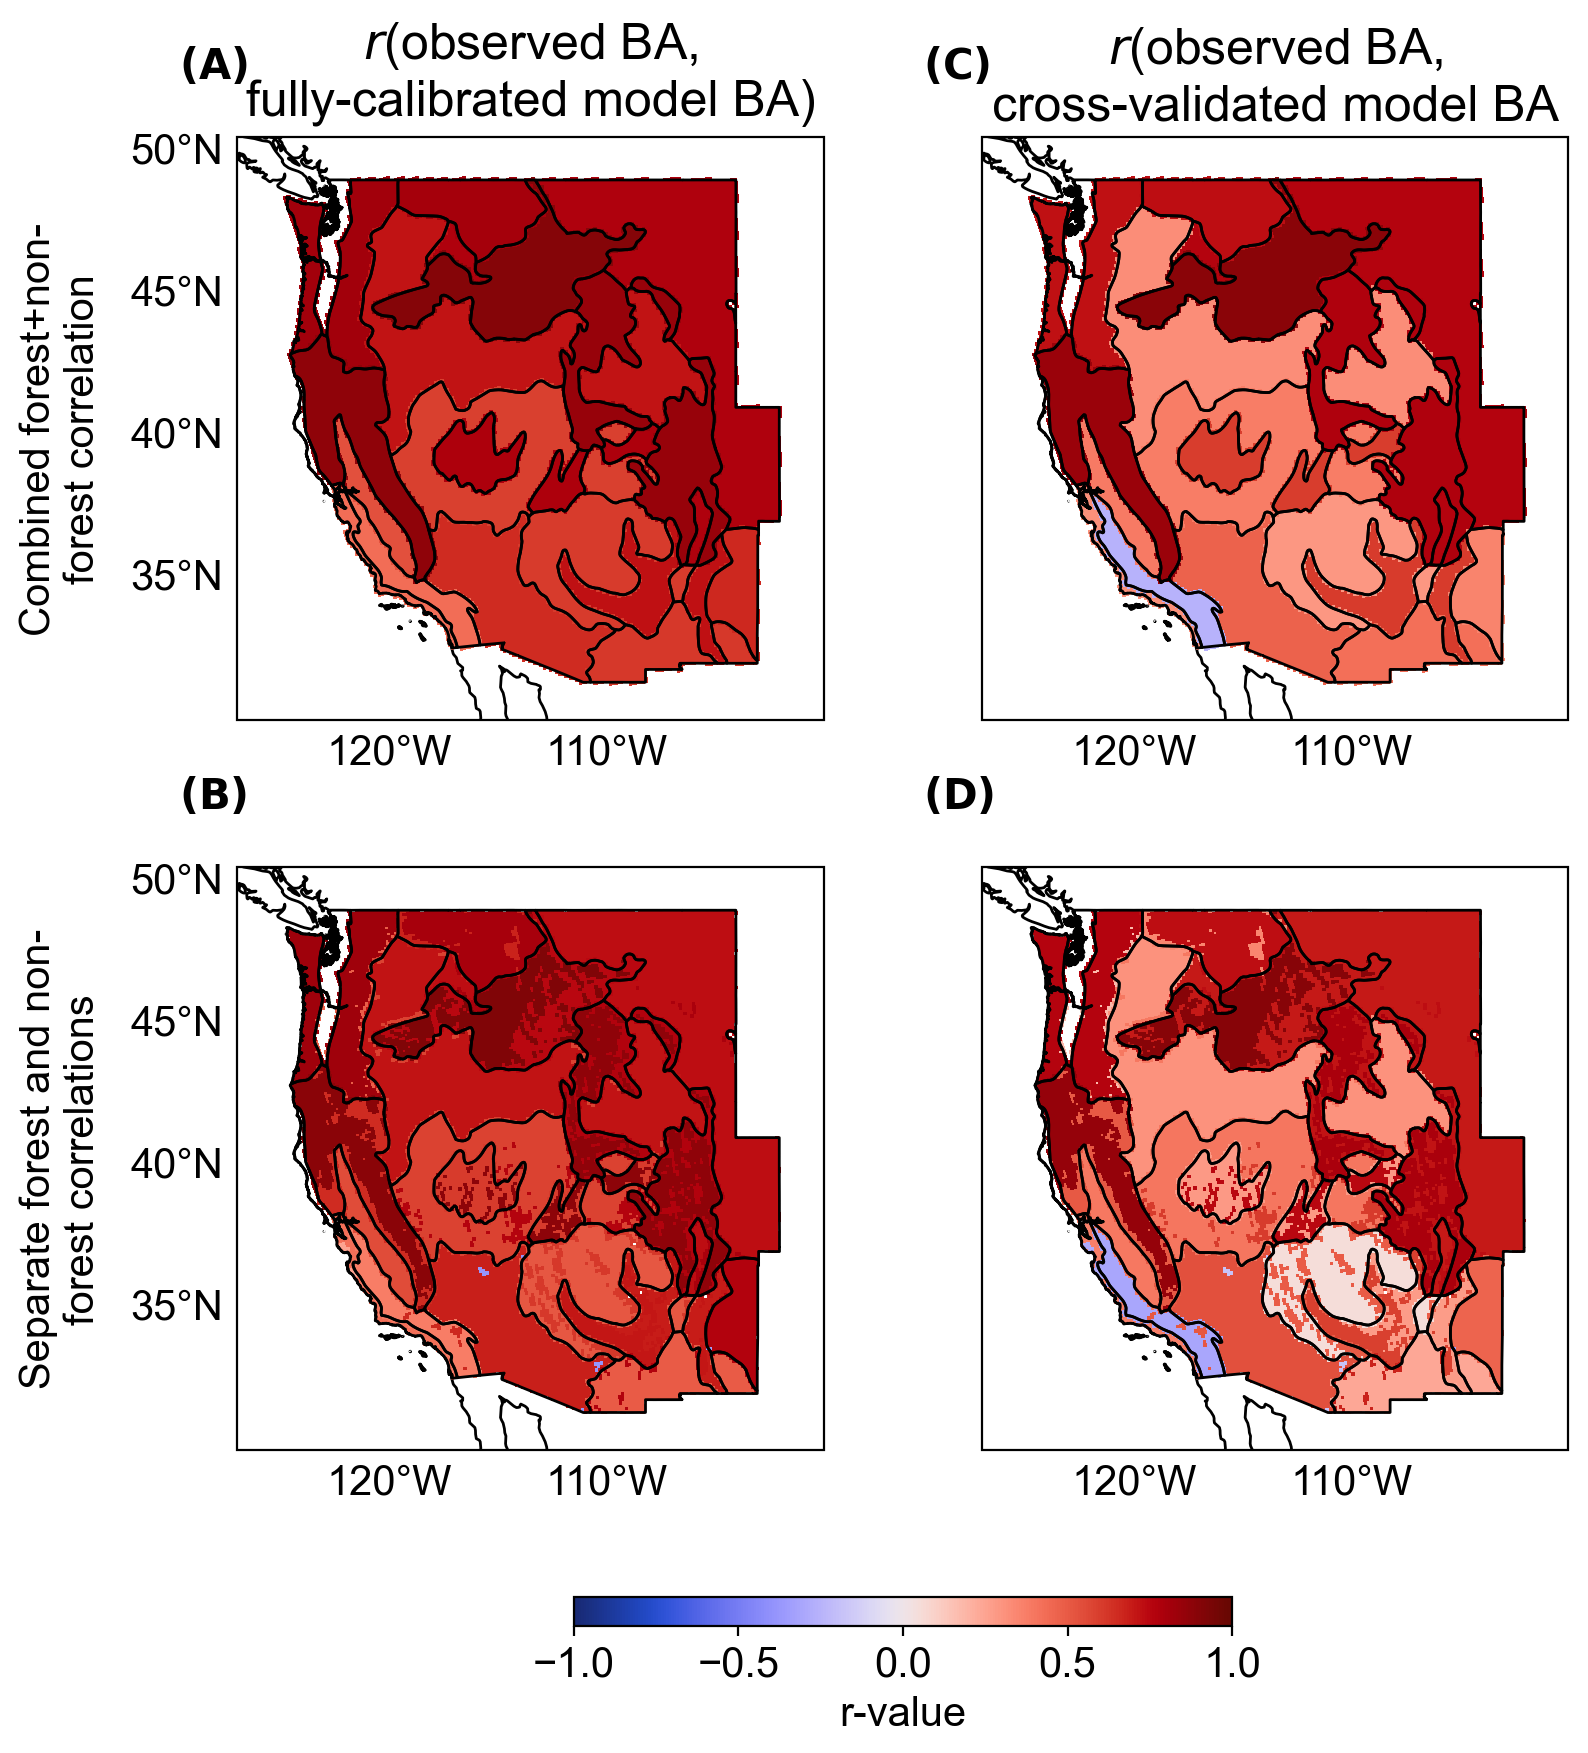

In [43]:
# 2x2 maps of all correlations,
# fully-calibrated model vs. cross-validated model
# top row: forest+nonforest
# bottom row: pixel divided into forest or nonforest

fig = plt.figure(figsize=(8,9), dpi=200)
gs = gridspec.GridSpec(3, 4, figure=fig, height_ratios=[1,1,0.05],
                      width_ratios=[1,1,1,1])
extent = [-127,-100,30,50]

######### left side top
ax1 = fig.add_subplot(gs[0,0:2],projection=ccrs.PlateCarree())
# add map features
ax1.set_extent(extent)
ax1.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the fully-calibrated data
for thisregnum in dfnum:
    xr.where((ecoreg.sel(province=thisregnum))>0,
            r_allfull[counter],np.nan).plot(
            ax=ax1, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    counter+=1

ax1.set_title('$r$(observed BA,\nfully-calibrated model BA)')
# grid
precgrid1 = ax1.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid1.top_labels = False
precgrid1.right_labels = False

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax1, zorder=2)

######### right side top
ax2 = fig.add_subplot(gs[0,2:4],projection=ccrs.PlateCarree())
# add map features
ax2.set_extent(extent)
ax2.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the cross-validated data
for thisregnum in dfnum:
    xr.where((ecoreg.sel(province=thisregnum))>0,
            r_allCV[counter],np.nan).plot(
            ax=ax2, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    counter+=1
ax2.set_title('$r$(observed BA,\ncross-validated model BA')

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax2, zorder=2)

# grid
precgrid2 = ax2.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid2.top_labels = False
precgrid2.right_labels = False
precgrid2.left_labels = False

######### left side bottom
ax3 = fig.add_subplot(gs[1,0:2],projection=ccrs.PlateCarree())
# add map features
ax3.set_extent(extent)
ax3.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the fully-calibrated data
for thisregnum in dfnum:
    xr.where((ecoregfor.sel(province=thisregnum))>0,
            r_forfull[counter],np.nan).plot(
            ax=ax3, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    xr.where((ecoregnon.sel(province=thisregnum))>0,
            r_nonfull[counter],np.nan).plot(
            ax=ax3, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor,
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=0)
    counter+=1

ax3.set_title(' ')

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax3, zorder=2)
# grid
precgrid2 = ax3.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid2.top_labels = False
precgrid2.right_labels = False

######### right side bottom
ax4 = fig.add_subplot(gs[1,2:4],projection=ccrs.PlateCarree())

# add map features
ax4.set_extent(extent)
ax4.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the cross-validated data
for thisregnum in dfnum:
    xr.where((ecoregfor.sel(province=thisregnum))>0,
            r_forCV[counter],np.nan).plot(
            ax=ax4, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    xr.where((ecoregnon.sel(province=thisregnum))>0,
            r_nonCV[counter],np.nan).plot(
            ax=ax4, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor,
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=0)
    counter+=1
ax4.set_title('')

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax4, zorder=2)
# grid
precgrid4 = ax4.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid4.top_labels = False
precgrid4.right_labels = False
precgrid4.left_labels = False


########## colorbars as separate gridspec
# following: https://www.sc.eso.org/~bdias/pycoffee/codes/20160407/gridspec_demo.html
cbplot1 = plt.subplot(gs[2,1:3])
# colorbar comes from prior jupyter cell
Colorbar(mappable=corrbar0, label='r-value', cmap=cmapcolor, 
         orientation='horizontal', ax=cbplot1)

fig.tight_layout()

# figure labels
ax1.annotate('Combined forest+non-\nforest correlation',(-0.3,0.5), 
             rotation=90, c='k', ha='center', va='center', xycoords='axes fraction')
ax3.annotate('Separate forest and non-\nforest correlations',(-0.3,0.5), 
             rotation=90, c='k',ha='center', va='center', xycoords='axes fraction')
# A   C
# B   D
ax1.annotate('$\\bf{(A)}$', (-0.1,1.1), c='k', xycoords='axes fraction')
ax3.annotate('$\\bf{(B)}$', (-0.1,1.1), c='k', xycoords='axes fraction')
ax2.annotate('$\\bf{(C)}$', (-0.1,1.1), c='k', xycoords='axes fraction')
ax4.annotate('$\\bf{(D)}$', (-0.1,1.1), c='k', xycoords='axes fraction')

fig.savefig(figfolder + 'Suppl_CrossValid_MapCorrAllFor+Non.png',
           bbox_inches="tight");

In [44]:
# print last time this model was updated
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print('Outputting for folder = ', climindname)
print("Model last run =", dt_string)

Outputting for folder =  patch125-155_nino3-34
Model last run = 26/06/2026 14:58:19
